# [기말 과제] 와인 품질 예측

**작성자**: 김준  
**날짜**: 2025-11-28

## 0. 요구사항 및 목표

### 0.1 과제 요구 사항

* 가능하면 적은 갯수의 필드로 Quality를 예측합니다.
* Quality 예측이 잘 되었는지 평가하는 기계학습 성능지표를 잘 선정해야 합니다.
* 학생이 선호하는 기계학습 알고리즘을 사용합니다.
* 사용하는 알고리즘이 파라미터를 많이 사용하는 것이라면, mlflow를 활용하는 것을 권장합니다.
* mlflow 사용했을 경우, mlruns 폴더 전체를 zip 파일로 archive 하여 제출합니다.
* 4000여개의 데이터를 제공하였고, 학생의 성과는 제공되지 않은 900여개의 데이터로 평가합니다.
* 간혹 이상치가 있을 수 있으니, 이상치를 제거하는 전처리 작업도 시행하여야 합니다

### 0.2 목표

* **데이터 엔지니어링 + 기계학습 + 설명 및 분석**
* `wine_data_homework.csv` 데이터를 활용하여 와인의 품질(Quality)을예측하는 모델을 개발하는 것을 목표로 합니다. 
* 단순한 모델링을 넘어, 데이터의 통계적 특성을 분석하고 양조학적 도메인지식을 활용한 피처 엔지니어링, 그리고 MLflow를 활용한 체계적인 실험 관리를수행합니다. 
* 각 단계의 의사결정 과정을 투명하게 시각화하여 논리적 타당성을 확보합니다. 
  * 코드 셀 앞 markdown 셀: 코드 셀의 목표, 사용 기법의 목적, 사용 기법의 원리, 사용 기법의 예상 결과
  * 코드 셀: 다양한 기법을 활용할 경우 성능평가 필요, 성능평가 및 결과 산출울 위한 다양한 시각화 자료
  * 코드 셀 뒤 markdown 셀: 코드 셀의 결과 분석, 결론
  
### 0.3 핵심 요구사항 및 해결 전략

1.  **Deep EDA**: 단순 분포 확인을 넘어, 품질(Quality) 등급별 변수의 차이를 비교 분석합니다.
1.1 데이터 구조 파악(통계 요약)
1.2 결측치 탐색 -> 결측치없음 확인인
1.3 변수 분포 확인('KDE plot', target 분포 확인) -> 클래스 불균형 확인 -> SMOTETomek 필요 확인
1.4 변수 간 관계 탐색(correlation heatmap) -> 다중공선성 확인
1.6 이상치 탐색(`Boxplot`) -> 이상치 탐색이 필요함 확인
1.6 target 과 관계 분석(`Boxplot`)
1. 데이터 분리
2.1 StratifiedKFold 로 train / test 분리
1. 이상치 처리
3.1 PCA 분석 -> PCA 로 IQR 과 Isolation Forest 이상치 비교해서 IF 선택택
1. 피처 엔지니어링
4.1 파생변수 생성
4.1 변수 간 관계 탐색(correlation heatmap) -> 피처 선택
4.2 VIF 확인 -> 피처 선택
4.3 분석 후 피처 선택
1. 샘플링
5.1 샘플링 방법 비교 -> SMOTETomek 
1. 정규화
6.1 스케일링 경쟁: Standard, MinMax, Robust, MaxAbs 스케일러를 비교하여 최적의 스케일러를 선정
1. 모델링
7.1 StratifiedKFold 데이터 나눔  
7.2 분류모델 - 모델 별 샘플링 정규화 적용
7.3 회귀모델 - 모델 별 샘플링 정규화 적용
7.4 두 접근 방식의 Accuracy, F1-Score, ROC-AUC를 정량적으로 비교하고 시각화하여 어떤 방식이 더 적합한지 결론을 도출
7.5 모델저장
7.6 모델 선정 분석 보고서
1. 모델 배포
8.1 새로운 데이터 로드 - 4001 번부터 데이터 사용
8.2 모델 사용용


9.  **이상치 처리**: 데이터의 노이즈를 줄이기 위해 IQR 및 Isolation Forest 기법을 비교 분석하여 최적의 이상치 제거 전략을 수립합니다.이상치 제거 전후의 데이터 손실과 분포 개선의 트레이드오프를 확인합니다.
10. **최소한의 피처 사용**: 다중공선성(Multicollinearity)을 피하고 모델의 일반화 성능을 높이기 위해 중요 변수(Feature Importance)를 선별합니다.
11. **MLflow 활용**: 하이퍼파라미터 튜닝 과정과 실험 결과를 MLflow로 추적하여 모델의 재현성을 확보합니다.
12. **일반화 성능 확보**: 과적합(Overfitting)을 방지하기 위해 교차 검증(Cross Validation)과 홀드아웃 테스트 셋을 엄격히 분리합니다.
13. **Model Evaluation**: 예측 결과의 잔차(Residual) 패턴과 혼동 행렬(Confusion Matrix)을 시각화하여 모델의 약점을 파악합니다.
14. **최종 검증**: 제공된 `wine-quality_searched.csv`의 특정 구간(4001~4897행)을 사용하여 최종 모델의 성능을 평가합니다.  



### 0.4 전체 분석 파이프라인 (Process Architecture)

데이터 로드 -> 데이터 확인 -> 


1.  **Data Loading & Split**: 데이터 로드 및 Train/Test 분리 (Data Leakage 원천 차단)
2.  **Deep EDA**: 분포 확인, 상관관계 분석, 시각화를 통한 인사이트 도출
3.  **Outlier Detection**: IQR vs Isolation Forest 비교 실험 및 적용
4.  **Feature Engineering**: 도메인 기반 파생 변수 생성 및 검증
5.  **Preprocessing**: Scaling, Encoding, Imbalance Handling (SMOTE)
6.  **Modeling & Optimization**: MLflow 기반 모델 비교 (ElasticNet, RF, XGBoost)
7.  **Evaluation & Interpretation**: SHAP 분석 및 잔차 분석
8.  **Final Deployment**: 히든 테스트 셋에 대한 최종 예측

---

## 1. xxxxxxx

### 1.1 환경설정 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import mlflow
import mlflow.sklearn

# 머신러닝 및 전처리 관련 라이브러리
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler, RobustScaler, MaxAbsScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, IsolationForest
from sklearn.linear_model import LogisticRegression, ElasticNet
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from xgboost import XGBRegressor
from sklearn.metrics import classification_report, cohen_kappa_score, make_scorer, mean_squared_error, mean_absolute_error, r2_score, accuracy_score, confusion_matrix
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

from statsmodels.stats.outliers_influence import variance_inflation_factor

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from catboost import CatBoostRegressor, CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.preprocessing import FunctionTransformer



# 시각화 설정 
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rc('font', family='Malgun Gothic') # 한글 폰트 설정
plt.rc('axes', unicode_minus=False)
warnings.filterwarnings('ignore')

# 재현성을 위한 시드 고정
SEED = 42
np.random.seed(SEED)

# MLflow 설정 (로컬 저장소 사용)
mlflow.set_tracking_uri("./mlruns")
mlflow.set_experiment("Wine_Quality_Expert_Viz")

# 1. 데이터 로드
try:
    df_full = pd.read_csv('wine_data_homework.csv', index_col=0)
    print("데이터 로드 완료. Shape:", df_full.shape)
except FileNotFoundError:
    print("파일을 찾을 수 없습니다. 경로를 확인해주세요.")

print("\n=== 기본 통계 정보 ===")
print(df_full.head())

데이터 로드 완료. Shape: (4001, 12)

=== 기본 통계 정보 ===
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.0              0.27         0.36            20.7      0.045   
1            6.3              0.30         0.34             1.6      0.049   
2            8.1              0.28         0.40             6.9      0.050   
3            7.2              0.23         0.32             8.5      0.058   
4            7.2              0.23         0.32             8.5      0.058   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 45.0                 170.0   1.0010  3.00       0.45   
1                 14.0                 132.0   0.9940  3.30       0.49   
2                 30.0                  97.0   0.9951  3.26       0.44   
3                 47.0                 186.0   0.9956  3.19       0.40   
4                 47.0                 186.0   0.9956  3.19       0.40   

   alcohol  quality  
0      8.8       

* 결과:
* 분석: 
* 결론:

### 1.2 구조 파악 및 결측치 파악

In [2]:
# 기본 정보 확인
print("=== 데이터 구조 파악 ===")
df_full.info()
df_full.describe()

# 결측치 확인
print("\n=== 데이터 결측치 확인 ===")
missing_values = df_full.isnull().sum()
print("Missing Values per Column:")
print(missing_values[missing_values > 0])
if missing_values.sum() > 0:
    print(f"총 결측치: {missing_values.sum()}개")
else:
    print("결측치가 없습니다.")


=== 데이터 구조 파악 ===
<class 'pandas.core.frame.DataFrame'>
Index: 4001 entries, 0 to 4000
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4001 non-null   float64
 1   volatile acidity      4001 non-null   float64
 2   citric acid           4001 non-null   float64
 3   residual sugar        4001 non-null   float64
 4   chlorides             4001 non-null   float64
 5   free sulfur dioxide   4001 non-null   float64
 6   total sulfur dioxide  4001 non-null   float64
 7   density               4001 non-null   float64
 8   pH                    4001 non-null   float64
 9   sulphates             4001 non-null   float64
 10  alcohol               4001 non-null   float64
 11  quality               4001 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 406.4 KB

=== 데이터 결측치 확인 ===
Missing Values per Column:
Series([], dtype: int64)
결측치가 없습니다.


In [3]:
# # 2. Train/Test Split (Data Leakage 방지)
# # Stratified Split을 사용하여 Quality 분포를 유지하며 분리
# X = df_train_full.drop('quality', axis=1)
# y = df_train_full['quality']

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=SEED, stratify=y
# )

# print("\n=== Train/Test Split 결과 ===")
# print(f"Train Set: {X_train.shape}, Test Set: {X_test.shape}")

#### 함수: Count plot

In [4]:
def plot_target_distribution(y_data, title="타겟 변수 분포 분석", xlabel="Quality Score", ylabel="Count", figsize=(10, 5), palette='viridis'):
    """
    타겟 변수의 분포를 Count Plot으로 시각화하고, 각 클래스의 비율(%)을 표시합니다.

    Args:
        y_data (pd.Series or np.array): 시각화할 타겟 변수 데이터 (e.g., y_train).
        title (str): 그래프의 제목.
        xlabel (str): x축 레이블.
        ylabel (str): y축 레이블.
        figsize (tuple): 그래프의 크기.
        palette (str): Seaborn 색상 팔레트.
    """
    if not isinstance(y_data, pd.Series):
        try:
            # y_data가 Series가 아니면 Series로 변환 시도
            y_data = pd.Series(y_data)
        except:
            print("오류: y_data는 pandas Series 또는 Series로 변환 가능한 형태여야 합니다.")
            return

    plt.figure(figsize=figsize)
    
    # 1. Count Plot 생성
    ax = sns.countplot(x=y_data, palette=palette)
    
    # 2. 막대 위에 비율(%) 표시
    total = len(y_data)
    low_class_percentages = 0
    high_class_percentages = 0
    low_class_count = 0
    high_class_count = 0
    for p in ax.patches:
        height = p.get_height()
        # 높이가 0이 아닌 경우에만 비율을 계산하고 표시
        if height > 0:
            percentage = '{:.1f}%'.format(100 * height / total)
            percentage_float = (100 * height / total)
            # x 좌표: 막대의 중앙
            x = p.get_x() + p.get_width() / 2
            # y 좌표: 막대 끝에서 약간 위에 위치
            y = height
            ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10)
            if percentage_float < (100 / 7):
                low_class_percentages = low_class_percentages + percentage_float
                low_class_count = low_class_count + 1
            else:
                high_class_percentages = high_class_percentages + percentage_float
                high_class_count = high_class_count + 1

    print("Low class percentages: ", low_class_percentages)
    print("High class percentages: ", high_class_percentages)
    print(f"Imbalance Ratio (IR): (다수 클래스 수({high_class_count})) / (소수 클래스 수({low_class_count})): {high_class_percentages} / {low_class_percentages}")
    
    # 3. 제목 및 레이블 설정
    plt.title(f'{title} - 클래스 불균형 확인', fontsize=15)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

#### 함수: 수치형 변수들의 분포 (`Histogram & KDE`)

In [5]:
# 수치형 변수들의 분포 (Histogram & KDE)
def plot_numerical_distribution(X_data, n_cols=3, bins=30, color='skyblue', figsize_per_row=4):
    """
    수치형 독립 변수들의 분포를 히스토그램과 KDE 플롯으로 시각화합니다.
    
    Args:
        X_data (pd.DataFrame): 독립 변수 데이터 (e.g., X_train).
        n_cols (int): 한 행에 표시할 서브플롯의 개수. 기본값은 3.
        bins (int): 히스토그램의 막대(bin) 개수.
        color (str): 플롯의 색상.
        figsize_per_row (int): 한 행당 높이 비율을 결정하는 값.
    """
    if X_data.empty:
        print("오류: X_data가 비어 있습니다.")
        return
        
    # 수치형 변수만 선택
    # 와인 데이터셋은 보통 모든 피처가 수치형이지만, 안전을 위해 필터링
    numerical_features = X_data.select_dtypes(include=np.number).columns
    
    if numerical_features.empty:
        print("오류: X_data에 시각화할 수 있는 수치형 변수가 없습니다.")
        return

    n_features = len(numerical_features)
    # 필요한 행의 개수 계산
    n_rows = (n_features + n_cols - 1) // n_cols

    # 전체 Figure 크기 설정
    plt.figure(figsize=(20, figsize_per_row * n_rows))
    
    print(f"총 {n_features}개의 수치형 피처 분포를 생성합니다.")

    # 각 피처에 대해 반복하며 서브플롯 생성
    for i, col in enumerate(numerical_features):
        plt.subplot(n_rows, n_cols, i + 1)
        
        # Histplot 생성 (kde=True로 KDE 곡선 함께 표시)
        sns.histplot(X_data[col], kde=True, bins=bins, color=color)
        
        plt.title(f'{col} Distribution', fontsize=14)
        plt.xlabel(col)
        plt.ylabel('Density / Count')
        
    plt.tight_layout()
    plt.show()

#### 함수: target 과 관계 분석(`Botplot`)

In [6]:
# 피처별 Quality 구분 능력 분석 (Boxplot)
def plot_feature_quality_boxplots(X_data, y_data, n_cols=3, figsize_per_row=5):
    """
    각 독립 변수(Feature)가 타겟 변수(Quality)에 따라 어떻게 분포하는지 Boxplot으로 시각화합니다.

    Args:
        X_data (pd.DataFrame): 독립 변수 데이터 (e.g., X_train).
        y_data (pd.Series): 타겟 변수 데이터 (e.g., y_train).
        n_cols (int): 한 행에 표시할 서브플롯의 개수. 기본값은 3.
        figsize_per_row (int): 한 행당 높이 비율을 결정하는 값. (전체 높이 = n_rows * figsize_per_row)
    """
    if X_data.empty:
        print("오류: X_data가 비어 있습니다.")
        return
    
    features = X_data.columns
    n_features = len(features)
    # 필요한 행의 개수 계산
    n_rows = (n_features + n_cols - 1) // n_cols

    # 전체 Figure 크기 설정
    plt.figure(figsize=(20, figsize_per_row * n_rows))

    print(f"총 {n_features}개의 피처에 대해 Quality별 Boxplot을 생성합니다.")

    # 각 피처에 대해 반복하며 서브플롯 생성
    for i, col in enumerate(features):
        plt.subplot(n_rows, n_cols, i + 1)
        
        # Boxplot으로 중앙값과 분포 비교
        # x축은 타겟 변수, y축은 현재 피처
        sns.boxplot(x=y_data, y=X_data[col], palette='coolwarm')
        
        plt.title(f'{col} vs Quality', fontsize=14, fontweight='bold')
        plt.xlabel('Quality Score')
        plt.ylabel(col)
        plt.grid(True, alpha=0.3)
        
    plt.tight_layout()
    plt.show()

#### 함수: 변수 간 상관관계 분석(`Correlation Heatmap`)

In [7]:
# selected_corr_features = []
# def visualize_and_classify_correlation(X_data, y_data, target_name='quality', high_threshold=0.2, medium_threshold=0.1):
#     """
#     변수 간 상관관계 Heatmap과 타겟 변수와의 상관관계 Barh 플롯을 생성하고,
#     상관계수 임계값에 따라 피처를 분류하여 선택된 피처 목록을 반환합니다.

#     Args:
#         X_data (pd.DataFrame): 독립 변수 데이터 (e.g., X_train).
#         y_data (pd.Series): 타겟 변수 데이터 (e.g., y_train).
#         target_name (str): 타겟 변수의 이름. 기본값은 'quality'.
#         high_threshold (float): 높은 상관관계의 임계값 (절댓값 기준).
#         medium_threshold (float): 중간 상관관계의 임계값 (절댓값 기준).

#     Returns:
#         list: 높은 상관관계와 중간 상관관계를 가진 피처 목록 (selected_corr_features).
#     """
    
#     # 1. 상관관계 계산
#     combined_df = pd.concat([X_data, y_data.rename(target_name)], axis=1)
#     correlation_matrix = combined_df.corr()
    
#     # 타겟 변수와의 상관관계 추출 및 내림차순 정렬
#     target_correlation = correlation_matrix[target_name].drop(target_name).sort_values(ascending=False)

#     # 2. 서브플롯 설정
#     fig, axes = plt.subplots(1, 2, figsize=(18, 8))
#     fig.suptitle('변수 간 상관관계 분석 및 타겟 변수와의 관계 시각화', fontsize=18, y=1.02)

#     # --- Subplot 1: 상관관계 Heatmap (Triangle Heatmap) ---
#     mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

#     sns.heatmap(correlation_matrix, annot=True, mask=mask, cmap='RdBu_r', 
#                 ax=axes[0], fmt='.2f', linewidths=0.5, vmin=-1, vmax=1, center=0,
#                 cbar_kws={'shrink': 0.8})
#     axes[0].set_title('변수 간 다중공선성 확인 (Correlation Heatmap)', fontsize=15)
#     axes[0].tick_params(axis='x', rotation=45)
#     axes[0].tick_params(axis='y', rotation=0)

#     # --- Subplot 2: 타겟 변수와의 상관관계 Barh ---
    
#     # Bar Plot 생성 (수평 막대 그래프)
#     bars = axes[1].barh(target_correlation.index, target_correlation.values, 
#                         color=np.where(target_correlation.values > 0, 'skyblue', 'salmon'))

#     axes[1].set_title(f'타겟 변수 ({target_name})와의 상관관계', fontsize=15)
#     axes[1].set_xlabel('상관계수 값')
#     axes[1].set_ylabel('특성 변수')
#     axes[1].set_xlim(-1, 1) # x축 범위를 -1에서 1로 설정

#     # 임계값 표시 (수직선)
#     axes[1].axvline(high_threshold, color='green', linestyle='--', linewidth=1.5, label=f'High Threshold ({high_threshold})')
#     axes[1].axvline(-high_threshold, color='green', linestyle='--', linewidth=1.5)
#     axes[1].axvline(medium_threshold, color='orange', linestyle=':', linewidth=1.5, label=f'Medium Threshold ({medium_threshold})')
#     axes[1].axvline(-medium_threshold, color='orange', linestyle=':', linewidth=1.5)
#     axes[1].legend(loc='lower right')

#     # 막대 끝에 값 표시
#     for bar in bars:
#         width = bar.get_width()
#         axes[1].text(width, bar.get_y() + bar.get_height()/2, 
#                      f'{width:.2f}',
#                      va='center', ha='left' if width > 0 else 'right',
#                      fontsize=10, color='black' if abs(width) < 0.8 else 'white')

#     plt.tight_layout(rect=[0, 0, 1, 0.98])
#     plt.show()

#     # --- 상관관계에 따른 변수 분류 및 저장 ---
#     high_corr_features = target_correlation[target_correlation.abs() > high_threshold].index.tolist()
#     medium_corr_features = target_correlation[(target_correlation.abs() > medium_threshold) & (target_correlation.abs() <= high_threshold)].index.tolist()
#     low_corr_features = target_correlation[target_correlation.abs() <= medium_threshold].index.tolist()

#     print("\n=== 상관관계에 따른 변수 분류 ===")
#     print(f"High correlation features with {target_name} (> {high_threshold}): {high_corr_features}")
#     print(f"Medium correlation features with {target_name} ({medium_threshold} < |r| <= {high_threshold}): {medium_corr_features}")
#     print(f"Low correlation features with {target_name} (<= {medium_threshold}): {low_corr_features}")

#     # 선택된 상관관계 변수 목록 반환
#     selected_corr_features = high_corr_features + medium_corr_features
#     print(f"\n선택된 상관관계 변수 목록 (High + Medium): {selected_corr_features}")
    
#     return selected_corr_features

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
selected_corr_features = {}
def visualize_and_classify_correlation(X_data, y_data, target_name='quality', high_threshold=0.2, medium_threshold=0.1):
    """
    변수 간 상관관계 Heatmap과 타겟 변수와의 상관관계 Barh 플롯을 생성하고,
    상관계수 임계값에 따라 피처를 분류하여 선택된 피처 딕셔너리를 반환합니다.

    Args:
        X_data (pd.DataFrame): 독립 변수 데이터 (e.g., X_train).
        y_data (pd.Series): 타겟 변수 데이터 (e.g., y_train).
        target_name (str): 타겟 변수의 이름. 기본값은 'quality'.
        high_threshold (float): 높은 상관관계의 임계값 (절댓값 기준).
        medium_threshold (float): 중간 상관관계의 임계값 (절댓값 기준).

    Returns:
        dict: 높은 상관관계와 중간 상관관계를 가진 피처와 그 절대값 상관계수 (selected_corr_features).
              Format: {'feature_name': abs(correlation_value)}
    """
    
    # 1. 상관관계 계산
    combined_df = pd.concat([X_data, y_data.rename(target_name)], axis=1)
    correlation_matrix = combined_df.corr()
    
    # 타겟 변수와의 상관관계 추출 및 내림차순 정렬
    target_correlation = correlation_matrix[target_name].drop(target_name).sort_values(ascending=False)

    # 2. 서브플롯 설정
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    fig.suptitle('변수 간 상관관계 분석 및 타겟 변수와의 관계 시각화', fontsize=18, y=1.02)

    # --- Subplot 1: 상관관계 Heatmap (Triangle Heatmap) ---
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

    sns.heatmap(correlation_matrix, annot=True, mask=mask, cmap='RdBu_r', 
                ax=axes[0], fmt='.2f', linewidths=0.5, vmin=-1, vmax=1, center=0,
                cbar_kws={'shrink': 0.8})
    axes[0].set_title('변수 간 다중공선성 확인 (Correlation Heatmap)', fontsize=15)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].tick_params(axis='y', rotation=0)

    # --- Subplot 2: 타겟 변수와의 상관관계 Barh ---
    
    # Bar Plot 생성 (수평 막대 그래프)
    bars = axes[1].barh(target_correlation.index, target_correlation.values, 
                        color=np.where(target_correlation.values > 0, 'skyblue', 'salmon'))

    axes[1].set_title(f'타겟 변수 ({target_name})와의 상관관계', fontsize=15)
    axes[1].set_xlabel('상관계수 값')
    axes[1].set_ylabel('특성 변수')
    axes[1].set_xlim(-1, 1) # x축 범위를 -1에서 1로 설정

    # 임계값 표시 (수직선)
    axes[1].axvline(high_threshold, color='green', linestyle='--', linewidth=1.5, label=f'High Threshold ({high_threshold})')
    axes[1].axvline(-high_threshold, color='green', linestyle='--', linewidth=1.5)
    axes[1].axvline(medium_threshold, color='orange', linestyle=':', linewidth=1.5, label=f'Medium Threshold ({medium_threshold})')
    axes[1].axvline(-medium_threshold, color='orange', linestyle=':', linewidth=1.5)
    axes[1].legend(loc='lower right')

    # 막대 끝에 값 표시
    for bar in bars:
        width = bar.get_width()
        axes[1].text(width, bar.get_y() + bar.get_height()/2, 
                     f'{width:.2f}',
                     va='center', ha='left' if width > 0 else 'right',
                     fontsize=10, color='black' if abs(width) < 0.8 else 'white')

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

    # --- 상관관계에 따른 변수 분류 및 저장 ---
    # abs()를 사용하여 절대값 기준으로 필터링
    high_corr_features = target_correlation[target_correlation.abs() > high_threshold].index.tolist()
    medium_corr_features = target_correlation[(target_correlation.abs() > medium_threshold) & (target_correlation.abs() <= high_threshold)].index.tolist()
    low_corr_features = target_correlation[target_correlation.abs() <= medium_threshold].index.tolist()

    print("\n=== 상관관계에 따른 변수 분류 ===")
    print(f"High correlation features with {target_name} (> {high_threshold}): {high_corr_features}")
    print(f"Medium correlation features with {target_name} ({medium_threshold} < |r| <= {high_threshold}): {medium_corr_features}")
    print(f"Low correlation features with {target_name} (<= {medium_threshold}): {low_corr_features}")

    # [수정됨] 선택된 상관관계 변수 딕셔너리 생성 (Feature Name : Abs(Correlation))
    # High와 Medium에 해당하는 변수들을 합친 리스트
    selected_features_list = high_corr_features + medium_corr_features
    
    # 딕셔너리 컴프리헨션을 이용해 {이름: 절대값} 형태로 저장
    selected_corr_features = {
        feature: abs(target_correlation[feature]) 
        for feature in selected_features_list
    }
    
    # 절대값 크기 순으로 내림차순 정렬 (선택 사항, 보기 좋게 하기 위함)
    selected_corr_features = dict(sorted(selected_corr_features.items(), key=lambda item: item[1], reverse=True))

    print(f"\n선택된 상관관계 변수 딕셔너리 (High + Medium, Abs Value):")
    print(selected_corr_features)
    
    return selected_corr_features

#### 함수: 다중공선성 분석(`VIF`)

In [9]:
def calculate_vif(df):
    """VIF 계산 함수 - 다중공선성 분석"""
    # 데이터프레임이 비어있거나 단일 열인 경우 처리
    if df.shape[1] == 0:
        return pd.DataFrame({'Features': [], 'VIF': []})
    
    vif = pd.DataFrame()
    vif["Features"] = df.columns
    
    # 단일 변수는 VIF가 정의되지 않거나 1.0
    if df.shape[1] == 1:
        vif["VIF"] = 1.0
    else:
        # variance_inflation_factor는 numpy 배열을 사용합니다.
        vif["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
        
    return vif.sort_values(by="VIF", ascending=False).reset_index(drop=True)

def run_vif_analysis(X_data, vif_threshold=10):
    """
    독립 변수의 VIF를 계산하고 시각화하며, VIF 임계값 미만인 피처 목록을 반환합니다. 
    (스케일링 전 기준 분석)

    Args:
        X_data (pd.DataFrame): 독립 변수 데이터 (e.g., X_train).
        vif_threshold (int): 다중공선성 판단 VIF 임계값. 기본값은 10.

    Returns:
        list: VIF 임계값 미만인 피처 목록.
    """
    if X_data.empty:
        print("오류: X_data가 비어 있습니다.")
        return []

    # 1. VIF 계산
    vif_results = calculate_vif(X_data)
    
    print(f"\nVIF 분석 결과 (VIF > {vif_threshold}: 다중공선성 의심):")
    print(vif_results)
    
    # 2. VIF 시각화
    plt.figure(figsize=(12, 6))
    
    # VIF 임계값 기준으로 색상 설정
    colors = ['red' if v > vif_threshold else 'green' for v in vif_results['VIF']]
    
    plt.barh(vif_results['Features'], vif_results['VIF'], color=colors)
    plt.axvline(x=vif_threshold, color='red', linestyle='--', label=f'VIF = {vif_threshold} (임계값)')
    
    plt.xlabel('VIF')
    plt.title('VIF (Variance Inflation Factor) - 다중공선성 분석', fontsize=15)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 3. VIF 기준 피처 선택
    vif_selected = vif_results[vif_results['VIF'] < vif_threshold]['Features'].tolist()
    vif_not_selected = vif_results[vif_results['VIF'] >= vif_threshold]['Features'].tolist()

    print(f"\nVIF < {vif_threshold}인 피처 ({len(vif_selected)}개): {vif_selected}")
    print(f"\nVIF >= {vif_threshold}인 피처 ({len(vif_not_selected)}개): {vif_not_selected}")

    return vif_selected, vif_not_selected

#### 함수: 데이터 전처리 확인(`Botplot`, `Histogram&KDE`, `correlation`, `VIF`)

In [10]:
# 데이터 전처리를 확인
# 피처별 Quality 구분 능력 분석 (Boxplot)
# 수치형 변수들의 분포 (Histogram & KDE)
# 상관관계 확인
# VIF 분석
# 스케일링 후 VIF 계산 (스케일링이 VIF에 영향을 줄 수 있음)
def check_data(X_data, y_data, stage="None"):
    """
    데이터 전처리를 확인합니다.

    Args:
        X_data (pd.DataFrame): 독립 변수 데이터 (e.g., X_train).
        y_data (pd.Series): 타겟 변수 데이터 (e.g., y_train).
    """
    # 피처별 Quality 구분 능력 분석 (Boxplot)
    plot_feature_quality_boxplots(X_data, y_data)
    # 수치형 변수들의 분포 (Histogram & KDE)
    plot_numerical_distribution(X_data)

    # VIF 분석
    selected_vif_features, _ = run_vif_analysis(X_data)
    # # 스케일링 후 VIF 계산 (스케일링이 VIF에 영향을 줄 수 있음)
    # print("=" * 20, "스케일링 후 VIF","=" * 20)
    # scaler_temp = StandardScaler()
    # X_scaled_temp = pd.DataFrame(
    #     scaler_temp.fit_transform(X_data),
    #     columns=X_data.columns
    # )
    # selected_vif_features = run_vif_analysis(X_scaled_temp)

    # 상관관계 확인
    selected_corr_features = visualize_and_classify_correlation(X_data[selected_vif_features], y_data, 
                                                        target_name='quality', 
                                                        high_threshold=0.2, 
                                                        medium_threshold=0.1)

    # 상관관계와 VIF 를 통한 변수 선택
    print(f"상관관계와 VIF를 통한 변수 선택({stage}): {len(selected_corr_features)}개 {selected_corr_features}")

#### 함수: 이상치 탐색(`IQR`)

In [11]:
def detect_outliers_iqr(df, n=1.5):
    """
    IQR 방법을 사용하여 데이터프레임 내의 이상치를 탐지하고,
    이상치로 판단된 행의 위치 인덱스(positional index)를 반환합니다.
    
    Args:
        df (pd.DataFrame): 이상치를 탐지할 데이터프레임 (예: X_train).
        n (float): IQR 배수 (일반적으로 1.5).
        
    Returns:
        np.array: 이상치로 판단된 행의 위치 기반 인덱스 배열.
    """
    
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    
    # 이상치 범위: Q1 - n*IQR ~ Q3 + n*IQR
    lower_bound = Q1 - n * IQR
    upper_bound = Q3 + n * IQR
    
    print("=== 이상치 탐지 범위 (Q1 - 1.5*IQR ~ Q3 + 1.5*IQR) ===")
    outlier_info = pd.DataFrame({
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound
    })
    print(outlier_info)

    # 1. 이상치 조건 (어떤 컬럼이라도 범위 밖에 있는 경우)
    outlier_condition = ((df < lower_bound) | (df > upper_bound)).any(axis=1)
    
    # 2. 이상치로 판단된 행의 위치 기반 인덱스를 찾기
    # np.where는 True인 값들의 인덱스를 튜플 형태로 반환합니다.
    # [0]을 사용하여 행 인덱스만 추출합니다.
    outlier_pos_indices = np.where(outlier_condition)[0]
    
    return outlier_pos_indices

#### 함수: 이상치 탐색(`Isolation Forest`)

In [12]:
# 4.2 Isolation Forest 방식
def detect_outliers_if(X):
    # contamination: 이상치 비율 예상치 (약 5%로 가정)
    clf = IsolationForest(max_samples='auto', random_state=SEED, contamination=0.05)
    preds = clf.fit_predict(X)
    return np.where(preds == -1)[0] # -1이 이상치


#### 함수: PCA

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

# --- 새로운 함수 추가: 두 방법 비교 시각화 ---
def compare_outliers_scatter(X_data, detect_iqr_func, detect_if_func, title="IQR vs Isolation Forest 이상치 비교 (PCA)"):
    """
    PCA를 사용하여 데이터 차원을 2D로 축소하고, IQR과 Isolation Forest로 탐지된
    이상치를 산점도로 시각적으로 비교하는 함수입니다.

    Args:
        X_data (pd.DataFrame): 독립 변수 데이터 (e.g., X_train).
        detect_iqr_func (function): IQR 이상치를 탐지하고 위치 인덱스를 반환하는 함수.
        detect_if_func (function): Isolation Forest 이상치를 탐지하고 위치 인덱스를 반환하는 함수.
        title (str): 그래프의 제목.
    """
    if X_data.empty:
        print("오류: X_data가 비어 있습니다.")
        return

    # 1. 데이터 전처리 및 PCA 수행
    
    # PCA는 스케일에 민감하므로 StandardScaler를 사용하여 데이터를 표준화합니다.
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_data)
    
    # PCA를 사용하여 2개의 주성분으로 축소
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    X_pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
    
    # 2. 두 가지 방법으로 이상치 탐지 및 마스킹
    
    # 탐지 함수 호출 (위치 인덱스를 반환)
    outliers_iqr_pos = detect_iqr_func(X_data)
    outliers_if_pos = detect_if_func(X_data)
    
    # 불리언 마스크 생성
    is_iqr_outlier = np.zeros(len(X_data), dtype=bool)
    is_if_outlier = np.zeros(len(X_data), dtype=bool)
    
    is_iqr_outlier[outliers_iqr_pos] = True
    is_if_outlier[outliers_if_pos] = True
    
    # 3. 데이터 포인트 분류
    # 0: 정상 (Normal), 1: IQR만 이상치, 2: IF만 이상치, 3: 둘 다 이상치
    outlier_type = np.zeros(len(X_data), dtype=int)
    
    outlier_type[(is_iqr_outlier) & (is_if_outlier)] = 3      # 3: 둘 다 이상치
    outlier_type[(is_iqr_outlier) & (~is_if_outlier)] = 1     # 1: IQR만 이상치
    outlier_type[(~is_iqr_outlier) & (is_if_outlier)] = 2     # 2: IF만 이상치
    
    X_pca_df['Outlier_Type'] = outlier_type
    
    # 4. 시각화 
    
    plt.figure(figsize=(10, 8))
    
    # 색상, 마커, 레이블 설정
    colors = {0: 'blue', 1: 'red', 2: 'green', 3: 'black'}
    markers = {0: 'o', 1: 'X', 2: 's', 3: '*'}
    labels = {
        0: '정상 데이터 (Normal)',
        1: 'IQR만 이상치 (단변량)',
        2: 'IF만 이상치 (다변량)',
        3: '둘 다 이상치 (Both)'
    }

    # 데이터 분류별 산점도 그리기
    for type_val, group in X_pca_df.groupby('Outlier_Type'):
        plt.scatter(group['PC1'], group['PC2'], 
                    c=colors[type_val], 
                    marker=markers[type_val], 
                    label=labels[type_val],
                    s=type_val * 40 + 50, # 이상치일수록 마커 크기 키움
                    alpha=0.6)

    plt.title(title, fontsize=15)
    plt.xlabel(f'주성분 1 (PC1, 설명 분산: {pca.explained_variance_ratio_[0]:.2f})')
    plt.ylabel(f'주성분 2 (PC2, 설명 분산: {pca.explained_variance_ratio_[1]:.2f})')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.show()

#### 함수: 2D Scatter Plot + Hue (두 변수의 조합 찾기)

가장 강력한 방법입니다. 두 변수를 X, Y축에 놓고, 점의 색깔(Hue)을 품질(Target)로 표시합니다.
* 무엇을 봐야 하는가?대각선 분리: 
  * 빨간 점(고품질)과 파란 점(저품질)이 대각선 방향으로 갈라지는지 봅니다.
  * 특정 영역 뭉침: 우상단이나 좌하단 구석에 특정 색깔이 몰려 있는지 봅니다.
* 파생변수 아이디어:
  * 만약 Fixed Acidity와 Volatile Acidity를 그렸는데 대각선으로 색깔이 나뉜다면?
  * $\rightarrow$ Total Acidity (두 변수의 합) 변수 생성.
  * 만약 Alcohol과 Density가 반비례하는데 고품질이 한쪽에 몰려 있다면?
  * $\rightarrow$ Alcohol / Density (비율) 변수 생성.

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations

def analyze_and_plot_interactions(df, target_col, min_corr=None, top_n=9):
    """
    모든 피처 쌍을 조합하여 사칙연산(+, -, *, /) 파생변수를 만들고,
    Target과의 상관관계가 높은 조합을 찾아 시각화합니다.
    
    Args:
        df (pd.DataFrame): 데이터프레임
        target_col (str or pd.Series): 타겟 컬럼
        min_corr (float): 선택할 최소 상관계수 절대값 (이 값 이상인 조합만 선택)
        top_n (int): 시각화할 최대 그래프 개수 (너무 많으면 느려지므로 제한, 기본값 9)
    """
    
    # 1. 안전장치: target_col이 Series면 이름 추출
    if isinstance(target_col, pd.Series):
        target_col = target_col.name

    # 2. 수치형 피처만 추출 (타겟 제외)
    features = df.drop(columns=[target_col], errors='ignore').select_dtypes(include='number').columns.tolist()
    
    # 타겟 데이터 확보
    y = df[target_col]
    
    print(f"🔍 총 {len(features)}개 피처로 {len(list(combinations(features, 2)))}개의 조합을 분석합니다...")
    
    # 3. 모든 조합에 대해 파생변수 생성 및 상관계수 테스트
    results = []
    
    for f1, f2 in combinations(features, 2):
        # 원본 데이터 가져오기
        d1, d2 = df[f1], df[f2]
        
        # 4가지 사칙연산 시도
        ops = {
            'plus': d1 + d2,
            'minus': d1 - d2,
            'multiply': d1 * d2,
            'divide': d1 / (d2.replace(0, np.nan)) # 0으로 나누기 방지
        }
        
        for op_name, new_val in ops.items():
            # 상관계수 계산 (절대값 기준)
            corr = new_val.corr(y)
            
            if not np.isnan(corr):
                results.append({
                    'f1': f1,
                    'f2': f2,
                    'operation': op_name,
                    'new_feature_name': f"{f1}_{op_name}_{f2}",
                    'corr_abs': abs(corr),
                    'corr_raw': corr
                })

    # 4. 상관계수 높은 순으로 정렬 및 중복 제거
    results_df = pd.DataFrame(results).sort_values(by='corr_abs', ascending=False)
    unique_combinations = results_df.drop_duplicates(subset=['f1', 'f2'])
    
    # [수정] min_corr 필터링 로직 적용
    if min_corr is not None:
        selected_combinations = unique_combinations[unique_combinations['corr_abs'] >= min_corr]
        print(f"🎯 상관계수(절대값) {min_corr} 이상인 조합 {len(selected_combinations)}개를 찾았습니다.")
    else:
        selected_combinations = unique_combinations
        
    if selected_combinations.empty:
        print("⚠️ 조건에 맞는 조합이 없습니다. min_corr 값을 낮춰보세요.")
        return selected_combinations

    # 시각화 개수 제한 (top_n)
    if top_n and len(selected_combinations) > top_n:
        print(f"ℹ️ 시각화는 가독성을 위해 상위 {top_n}개만 출력합니다. (전체 결과는 반환된 데이터프레임 확인)")
        plot_combinations = selected_combinations.head(top_n)
    else:
        plot_combinations = selected_combinations

    print("-" * 60)
    print(plot_combinations[['new_feature_name', 'corr_raw']].to_string(index=False))
    print("-" * 60)

    # 5. 시각화 (Subplots 생성)
    num_plots = len(plot_combinations)
    cols = 3
    rows = (num_plots + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    # axes가 1개일 경우 배열이 아닐 수 있으므로 처리
    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten() 
    
    sns.set_theme(style="whitegrid")

    for i, (_, row) in enumerate(plot_combinations.iterrows()):
        ax = axes[i]
        
        # Scatter Plot 그리기
        sns.scatterplot(
            data=df,
            x=row['f1'],
            y=row['f2'],
            hue=target_col,
            palette='RdYlBu_r',
            alpha=0.6,
            s=20,
            ax=ax
        )
        
        # 제목에 추천 파생변수와 상관계수 표시
        ax.set_title(f"Rank {i+1}: {row['f1']} vs {row['f2']}\n(Best: {row['operation']}, r={row['corr_raw']:.2f})", fontsize=11)
        ax.legend([],[], frameon=False) 

    # 남은 빈 서브플롯 끄기
    if num_plots > 1:
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    return selected_combinations # 필터링된 전체 결과 반환

# --- 실행 예시 ---
# analyze_and_plot_interactions(df_full, target_col='quality', min_corr=0.4, top_n=9)

#### 함수: 파생변수를 데이터프레임에 생성

In [15]:
def create_derived_features(df, combinations_info):
    """
    분석 결과(combinations_info)를 바탕으로 실제 파생변수를 데이터프레임에 생성합니다.
    
    Args:
        df (pd.DataFrame): 원본 데이터프레임 (Train 또는 Test)
        combinations_info (pd.DataFrame): analyze_and_plot_interactions 함수의 리턴값
                                          (필요한 컬럼: 'f1', 'f2', 'operation', 'new_feature_name')
                                          
    Returns:
        pd.DataFrame: 파생변수가 추가된 새로운 데이터프레임
    """
    df_new = df.copy()
    
    if combinations_info.empty:
        print("⚠️ 생성할 파생변수 정보가 없습니다.")
        return df_new

    print(f"🛠️ 총 {len(combinations_info)}개의 파생변수를 생성합니다...")
    
    for _, row in combinations_info.iterrows():
        f1 = row['f1']
        f2 = row['f2']
        op = row['operation']
        col_name = row['new_feature_name']
        
        # 컬럼이 존재하는지 확인
        if f1 not in df_new.columns or f2 not in df_new.columns:
            print(f"⚠️ 경고: {f1} 또는 {f2} 컬럼이 데이터에 없어 '{col_name}' 생성을 건너뜁니다.")
            continue

        try:
            if op == 'plus':
                df_new[col_name] = df_new[f1] + df_new[f2]
            elif op == 'minus':
                df_new[col_name] = df_new[f1] - df_new[f2]
            elif op == 'multiply':
                df_new[col_name] = df_new[f1] * df_new[f2]
            elif op == 'divide':
                # 0으로 나누기 방지 (np.inf 방지)
                df_new[col_name] = df_new[f1] / (df_new[f2].replace(0, np.nan))
                # 나눗셈으로 생긴 NaN 값 처리 (선택 사항, 여기서는 0으로 채움)
                df_new[col_name] = df_new[col_name].fillna(0)
                
        except Exception as e:
            print(f"❌ 에러 발생 ({col_name}): {e}")

    print(f"✅ 생성 완료! (컬럼 수: {df.shape[1]} -> {df_new.shape[1]})")
    return df_new

# --- 실행 예시 ---
# 1. Train Set에서 좋은 파생변수 찾기 (최소 상관계수 0.3 이상인 것만)
# top_features_df = analyze_and_plot_interactions(X_train.join(y_train), target_col='quality', min_corr=0.3, top_n=9)

# 2. Train Set에 적용
# X_train_eng = create_derived_features(X_train, top_features_df)

# 3. Test Set에도 동일한 규칙(top_features_df) 적용 (Data Leakage 방지)
# X_test_eng = create_derived_features(X_test, top_features_df)

#### 함수: 가장 높은 상관계수를 가진 변수부터 우선 선택하되, 이미 선택된 변수의 구성요소(f1, f2)와 겹치면 제외하는 Greedy(탐욕) 알고리즘

In [16]:
def classify_features_by_keywords(df, target_keywords):
    """
    df의 파생 변수와 target_keywords의 단일 변수 중, 
    구성 요소(f1, f2, key)가 서로 겹치지 않으면서 
    상관계수(절대값)가 가장 높은 변수들을 우선적으로 선택하여 반환합니다.

    Args:
        df (pd.DataFrame): 'f1', 'f2', 'new_feature_name', 'corr_abs' 컬럼을 포함한 데이터프레임
        target_keywords (dict): {'feature_name': correlation_value} 형태의 딕셔너리 
                                (예: {'alcohol': 0.4617, ...})
        
    Returns:
        dict: 선택된 변수명과 그 상관계수 값 {'feature_name': score}
    """
    
    # 1. 모든 후보군을 하나의 리스트로 통합
    candidates = []

    # 1-1. df에서 후보 추출 (f1 != f2 인 경우만)
    # iterrows를 사용하여 각 행의 정보를 딕셔너리로 변환
    filtered_df = df[df['f1'] != df['f2']]
    for _, row in filtered_df.iterrows():
        candidates.append({
            'name': row['new_feature_name'],
            'score': row['corr_abs'],
            'components': {row['f1'], row['f2']}, # 비교를 위해 set으로 저장
            'type': 'derived'
        })
        
    # 1-2. target_keywords에서 후보 추출
    for key, value in target_keywords.items():
        candidates.append({
            'name': key,
            'score': value,  # 이미 절대값 혹은 비교 가능한 수치라고 가정
            'components': {key}, # 단일 변수이므로 자기 자신이 구성요소
            'type': 'base'
        })
    
    # 2. 상관계수(score) 기준으로 내림차순 정렬 (높은 점수 우선)
    # 점수가 높은 순서대로 루프를 돌며 선택 여부를 결정합니다.
    candidates.sort(key=lambda x: x['score'], reverse=True)
    
    # 3. 중복 방지 선택 로직 (Greedy Algorithm)
    selected_features = {}
    used_components = set() # 이미 선택된 변수들의 구성요소를 저장하는 집합

    print(f"{'Rank':<5} | {'Score':<10} | {'Type':<10} | {'Feature Name'}")
    print("-" * 60)

    for i, cand in enumerate(candidates):
        # 현재 후보의 구성요소가 이미 사용된 구성요소와 겹치는지 확인
        # intersection() 결과가 있으면(=True) 겹치는 것
        if not cand['components'].intersection(used_components):
            
            # 겹치지 않으면 선택!
            selected_features[cand['name']] = cand['score']
            
            # 사용된 구성요소 목록에 추가 (Lock)
            used_components.update(cand['components'])
            
            print(f"{i+1:<5} | {cand['score']:.6f}   | {cand['type']:<10} | {cand['name']} (Selected)")
        else:
            # 겹치면 패스 (로그 확인용)
            # print(f"{i+1:<5} | {cand['score']:.6f} | {cand['type']:<10} | {cand['name']} (Skipped - Overlap)")
            pass

    return selected_features

## 2. 심화 탐색적 데이터 분석 (Advanced EDA)

단순한 분포 확인을 넘어, 각 피처가 품질(Quality) 결정에 미치는 영향을 시각적으로 파헤칩니다.

### 2.1 Advanced EDA 를 위한 데이터 분리(X, y)

In [17]:
target = 'quality'
X_eda = df_full.drop(target, axis=1)
y_eda = df_full[target]

### 2.2 변수 분포 확인 (`Countplot`:target)

Low class percentages:  8.04798800299925
High class percentages:  91.95201199700075
Imbalance Ratio (IR): (다수 클래스 수(3)) / (소수 클래스 수(4)): 91.95201199700075 / 8.04798800299925


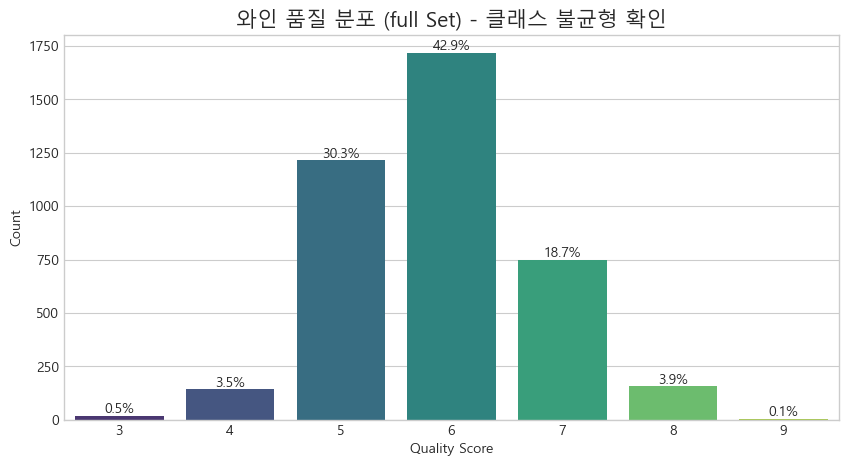

In [18]:
plot_target_distribution(y_eda, 
                         title="와인 품질 분포 (full Set)", 
                         xlabel="Quality Score")

### 분석: Quality 분포 시각화 결과
- **시각화 해석**: 위 그래프는 데이터의 클래스 불균형(IR 비율이 20% 이하)을 명확히 보여줍니다. 6점이 가장 많고 5점, 7점 순이며, **3, 4, 8, 9점은 극소수**입니다.
- **결론**: 이러한 불균형을 해결하지 않고 모델을 학습하면 다수 클래스(5, 6, 7)로 편향될 것입니다. 따라서 후속 단계에서 **SMOTE 계열의 오버샘플링이 필수적**임을 시각적으로 확인했습니다.

### 2.3 변수 분포 확인(`KDE plot`)

총 11개의 수치형 피처 분포를 생성합니다.


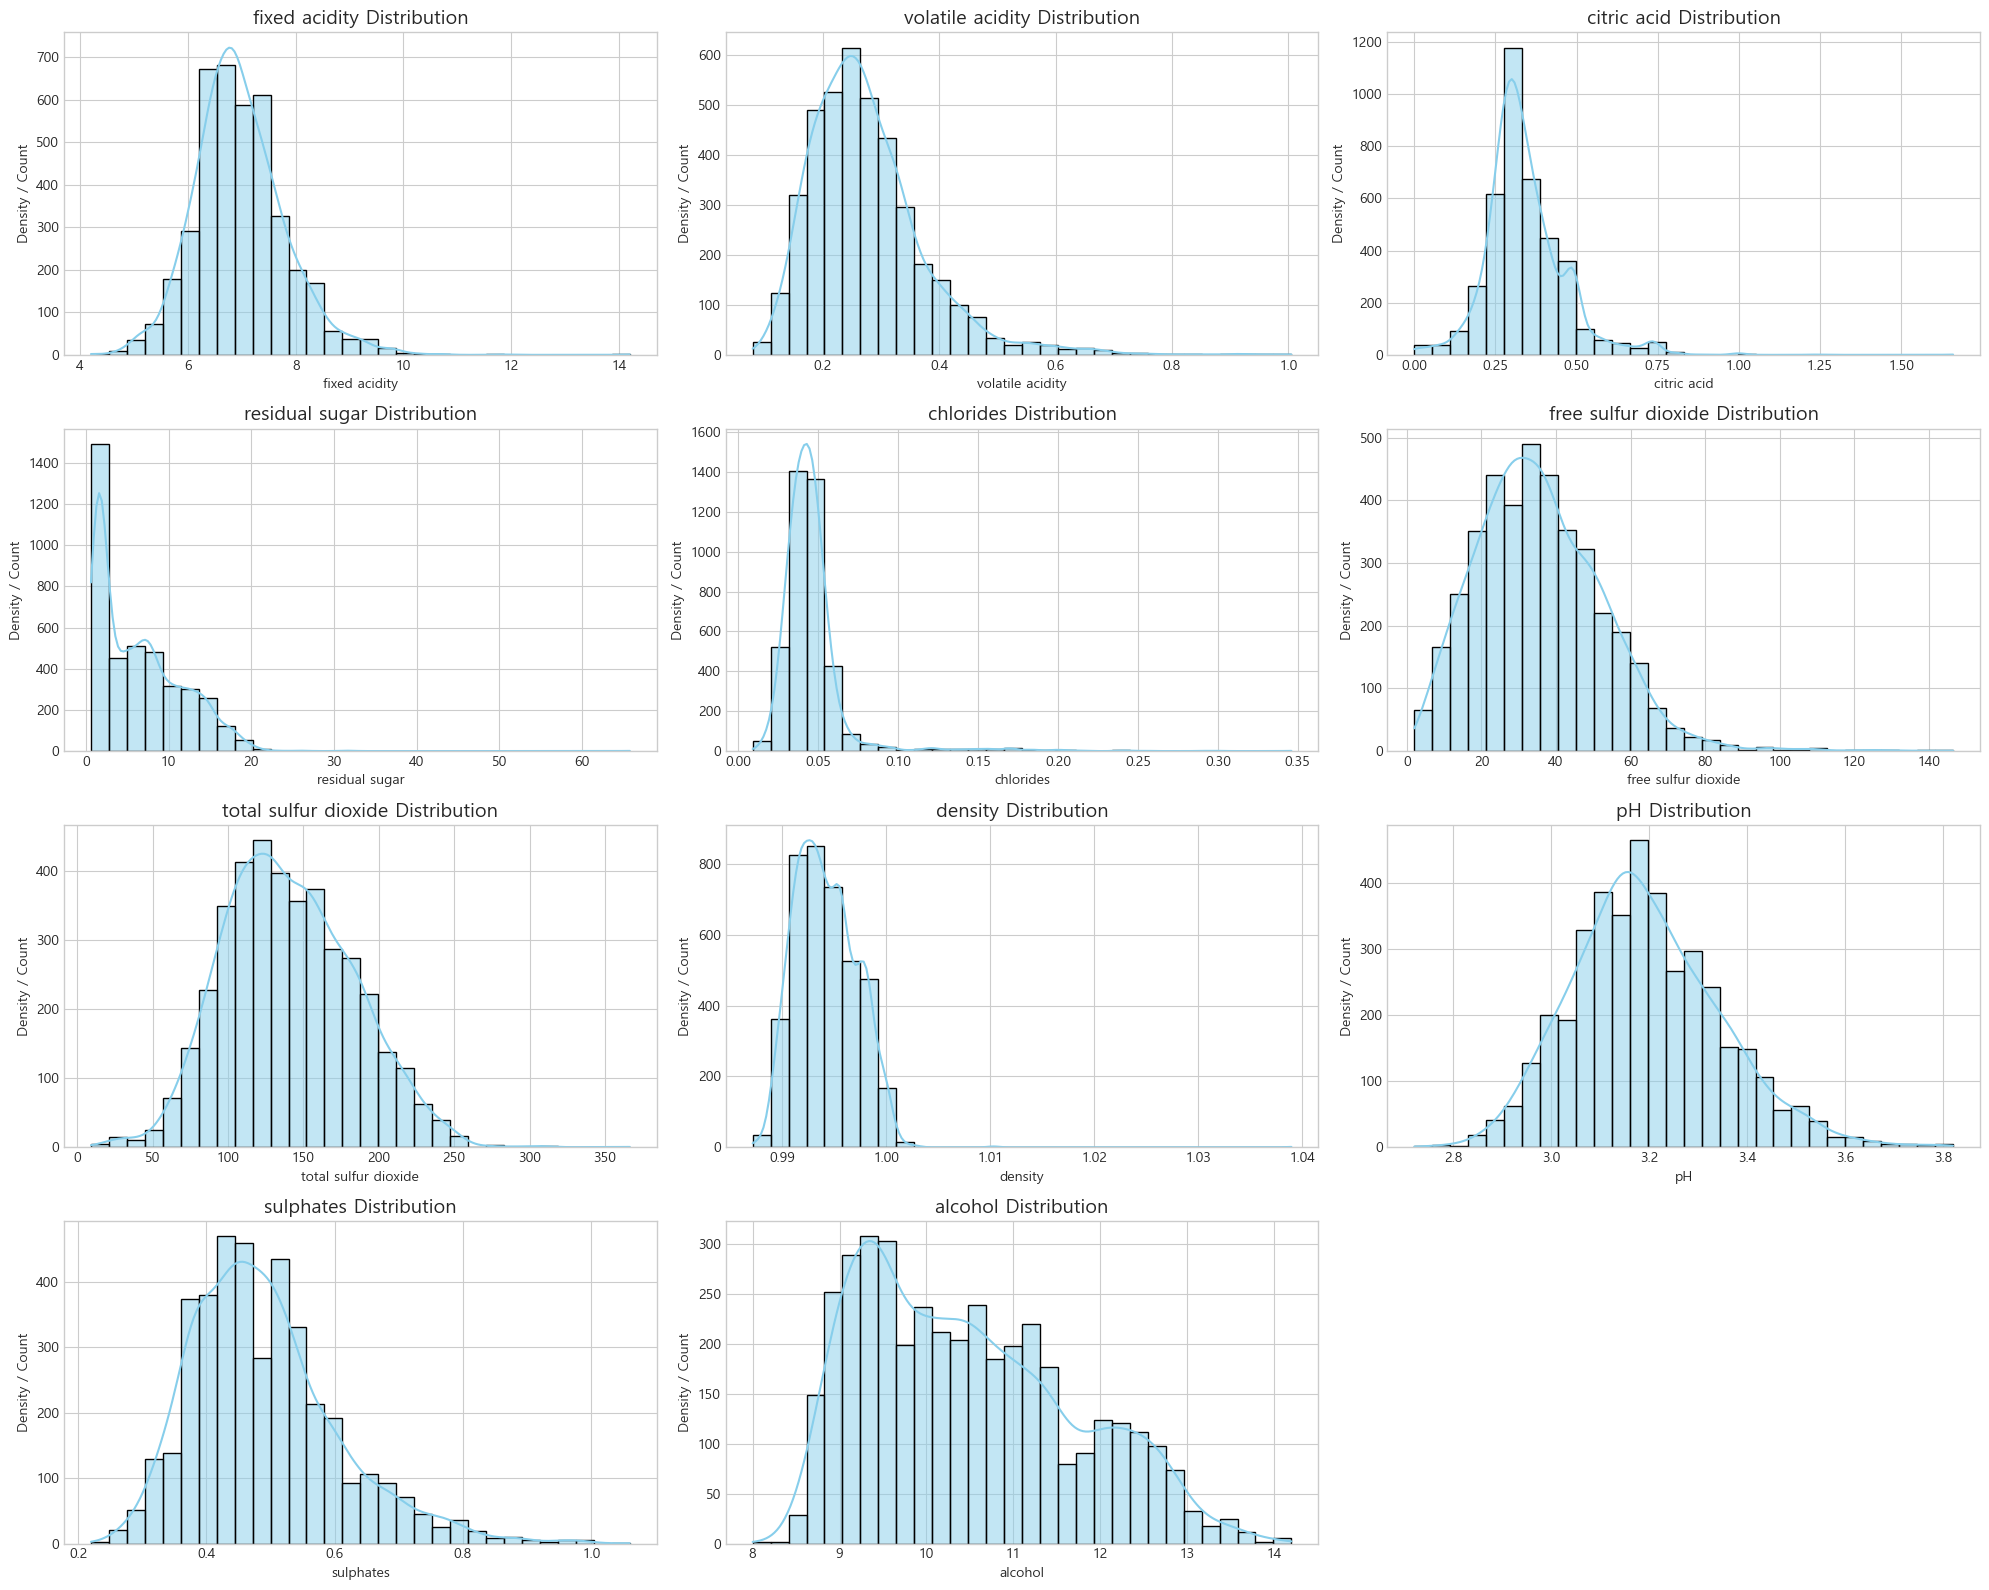

In [19]:
plot_numerical_distribution(X_eda)

### 분석: 데이터 분포 확인
- **불균형 데이터**: `residual sugar`, `chlorides` 등의 변수는 오른쪽으로 긴 꼬리(Right Skewed) 분포를 보입니다. 이는 정규성을 가정하는 일부 모델(선형 회귀 등)에 악영향을 줄 수 있으므로 **정규화**(**로그 변환**이나 **Robust Scaler**) 사용을 고려해야 합니다.

In [20]:
# plot_feature_quality_boxplots(X_train, y_train)

### 2.4 변수 간 관계 탐색(correlation heatmap)

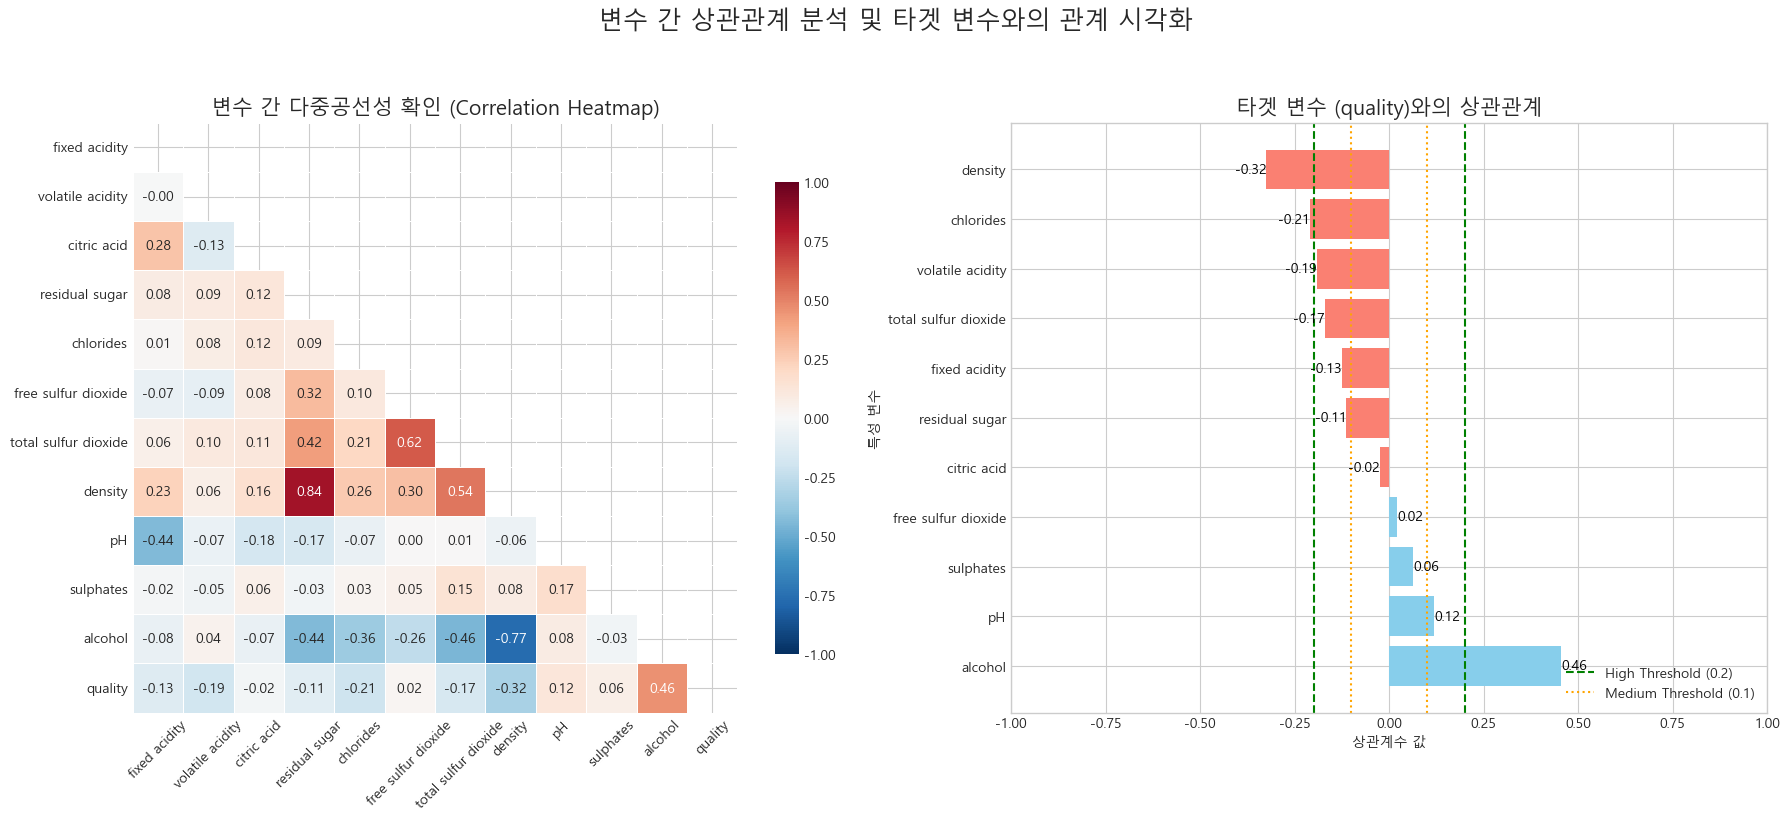


=== 상관관계에 따른 변수 분류 ===
High correlation features with quality (> 0.2): ['alcohol', 'chlorides', 'density']
Medium correlation features with quality (0.1 < |r| <= 0.2): ['pH', 'residual sugar', 'fixed acidity', 'total sulfur dioxide', 'volatile acidity']
Low correlation features with quality (<= 0.1): ['sulphates', 'free sulfur dioxide', 'citric acid']

선택된 상관관계 변수 딕셔너리 (High + Medium, Abs Value):
{'alcohol': np.float64(0.45519495928220133), 'density': np.float64(0.32465025139356724), 'chlorides': np.float64(0.20955653962744716), 'volatile acidity': np.float64(0.19142436790265446), 'total sulfur dioxide': np.float64(0.17063878019225792), 'fixed acidity': np.float64(0.12600591640659528), 'pH': np.float64(0.11915172512134131), 'residual sugar': np.float64(0.11320294127528961)}
상관관계가 높은 피처:8개 {'alcohol': np.float64(0.45519495928220133), 'density': np.float64(0.32465025139356724), 'chlorides': np.float64(0.20955653962744716), 'volatile acidity': np.float64(0.19142436790265446), 'total sulf

In [21]:
selected_corr_features = visualize_and_classify_correlation(X_eda, y_eda, 
                                                       target_name='quality', 
                                                       high_threshold=0.2, 
                                                       medium_threshold=0.1)

print(f"상관관계가 높은 피처:{len(selected_corr_features)}개 {selected_corr_features}")

### 분석: 히트맵을 통한 다중공선성 확인
- **강한 음의 상관관계**: `Alcohol`과 `Density` (-0.76). 밀도가 높으면 알코올 도수가 낮은 경향이 있습니다.
- **강한 양의 상관관계**: `Free Sulfur Dioxide`와 `Total Sulfur Dioxide` (0.61). 이는 화학적으로 당연한 귀결입니다. `residual sugar`와 `density` (0.84). 당분이 많으면 밀도가 높아집니다.
- **결론**: 상관관계가 너무 높은 변수 쌍(0.6 이상)이 존재한다면, 둘 중 하나를 제거하거나 두 변수를 결합하여 새로운 파생 변수를 만드는 것이 모델의 안정성을 높이는 데 도움이 됩니다.

### 분석: Boxplot을 통한 변수별 영향력 확인
- **Alcohol**: Quality가 높아질수록(오른쪽으로 갈수록) Box의 위치가 상승하는 경향이 뚜렷합니다. 이는 **가장 강력한 예측 변수**임을 암시합니다.
- **Density**: Alcohol과 반대로 Quality가 높을수록 낮아지는 경향을 보입니다. (Alcohol과 Density는 음의 상관관계가 높기 때문)
- **Volatile Acidity**: 품질이 나쁜 와인(3, 4점)에서 수치가 높게 나타나며, 품질이 좋을수록 낮아집니다. 이는 식초 냄새(휘발성 산)가 품질 저하의 원인임을 보여줍니다.
- **결론**: 단순히 모든 변수를 넣기보다, Boxplot에서 등급 간 차이가 뚜렷한 변수(Alcohol, Volatile Acidity 등)가 모델에서 높은 중요도를 가질 것으로 예상됩니다.


VIF 분석 결과 (VIF > 10: 다중공선성 의심):
                Features          VIF
0                density  1063.437876
1                     pH   602.446409
2                alcohol   118.318156
3          fixed acidity    95.565662
4   total sulfur dioxide    25.023359
5              sulphates    20.513450
6            citric acid    10.123976
7       volatile acidity     9.678009
8    free sulfur dioxide     9.523727
9              chlorides     6.397235
10        residual sugar     3.803833


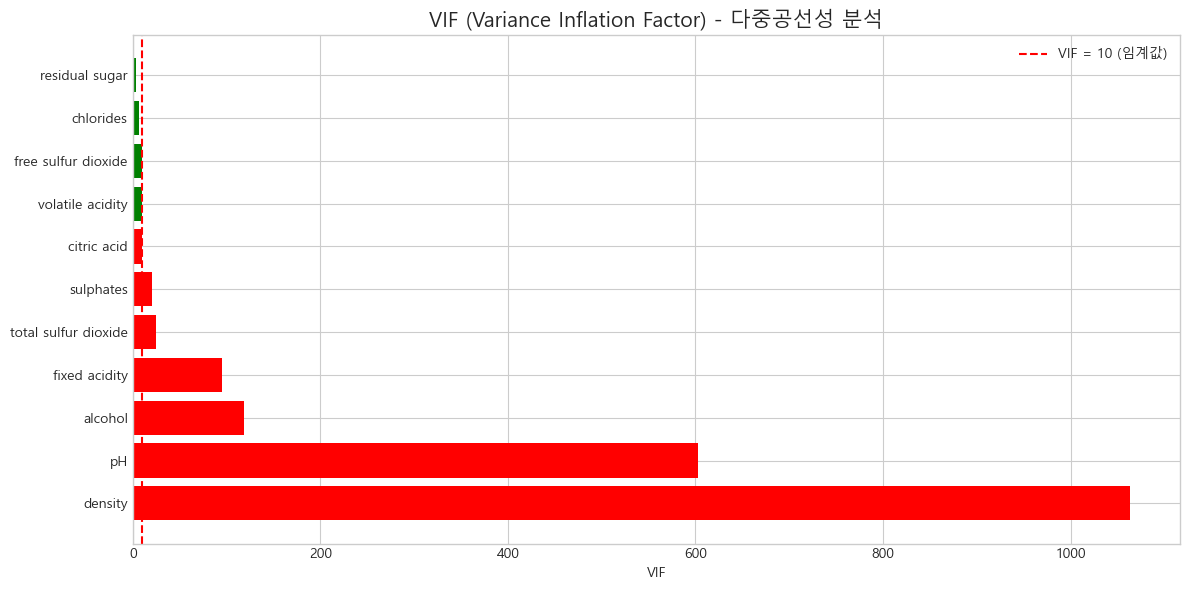


VIF < 10인 피처 (4개): ['volatile acidity', 'free sulfur dioxide', 'chlorides', 'residual sugar']

VIF >= 10인 피처 (7개): ['density', 'pH', 'alcohol', 'fixed acidity', 'total sulfur dioxide', 'sulphates', 'citric acid']


In [22]:
selected_vif_features, selected_vif_not_features = run_vif_analysis(X_eda)

### 분석: VIF 를 통한 다중공선성 확인
* 시각화 해석: 스케일링 전후 VIF에 큰 차이가 있었으며, 이는 데이터 스케일이 다중공선성에 미치는 영향을 보여줍니다. 스케일링 후에도 `density` 와 `residual sugar` 같은 일부 변수들은 여전히 높은 VIF를 보여 다중공선성이 강합니다. 
* 결론: 따라서 모델의 안정성을 위해 VIF가 10 이상인 `density` 및 `residual sugar` 변수를 **필터링**하는 것을 고려해야 합니다. 또한, **스케일링**이 다중공선성에 미치는 영향을 보여주므로, 스케일링을 적용하는 것이 모델의 안정성을 높이는 데 도움이 될 수 있습니다.
* 다중공선성: 여러 feature가 서로 너무 닮아서 모델이 어떤 변수가 실제로 영향을 주는지 구분하기 어려운 상태

### 2.5 이상치 탐색(`Boxplot`) -> 이상치 탐색이 필요함 확인

총 11개의 피처에 대해 Quality별 Boxplot을 생성합니다.


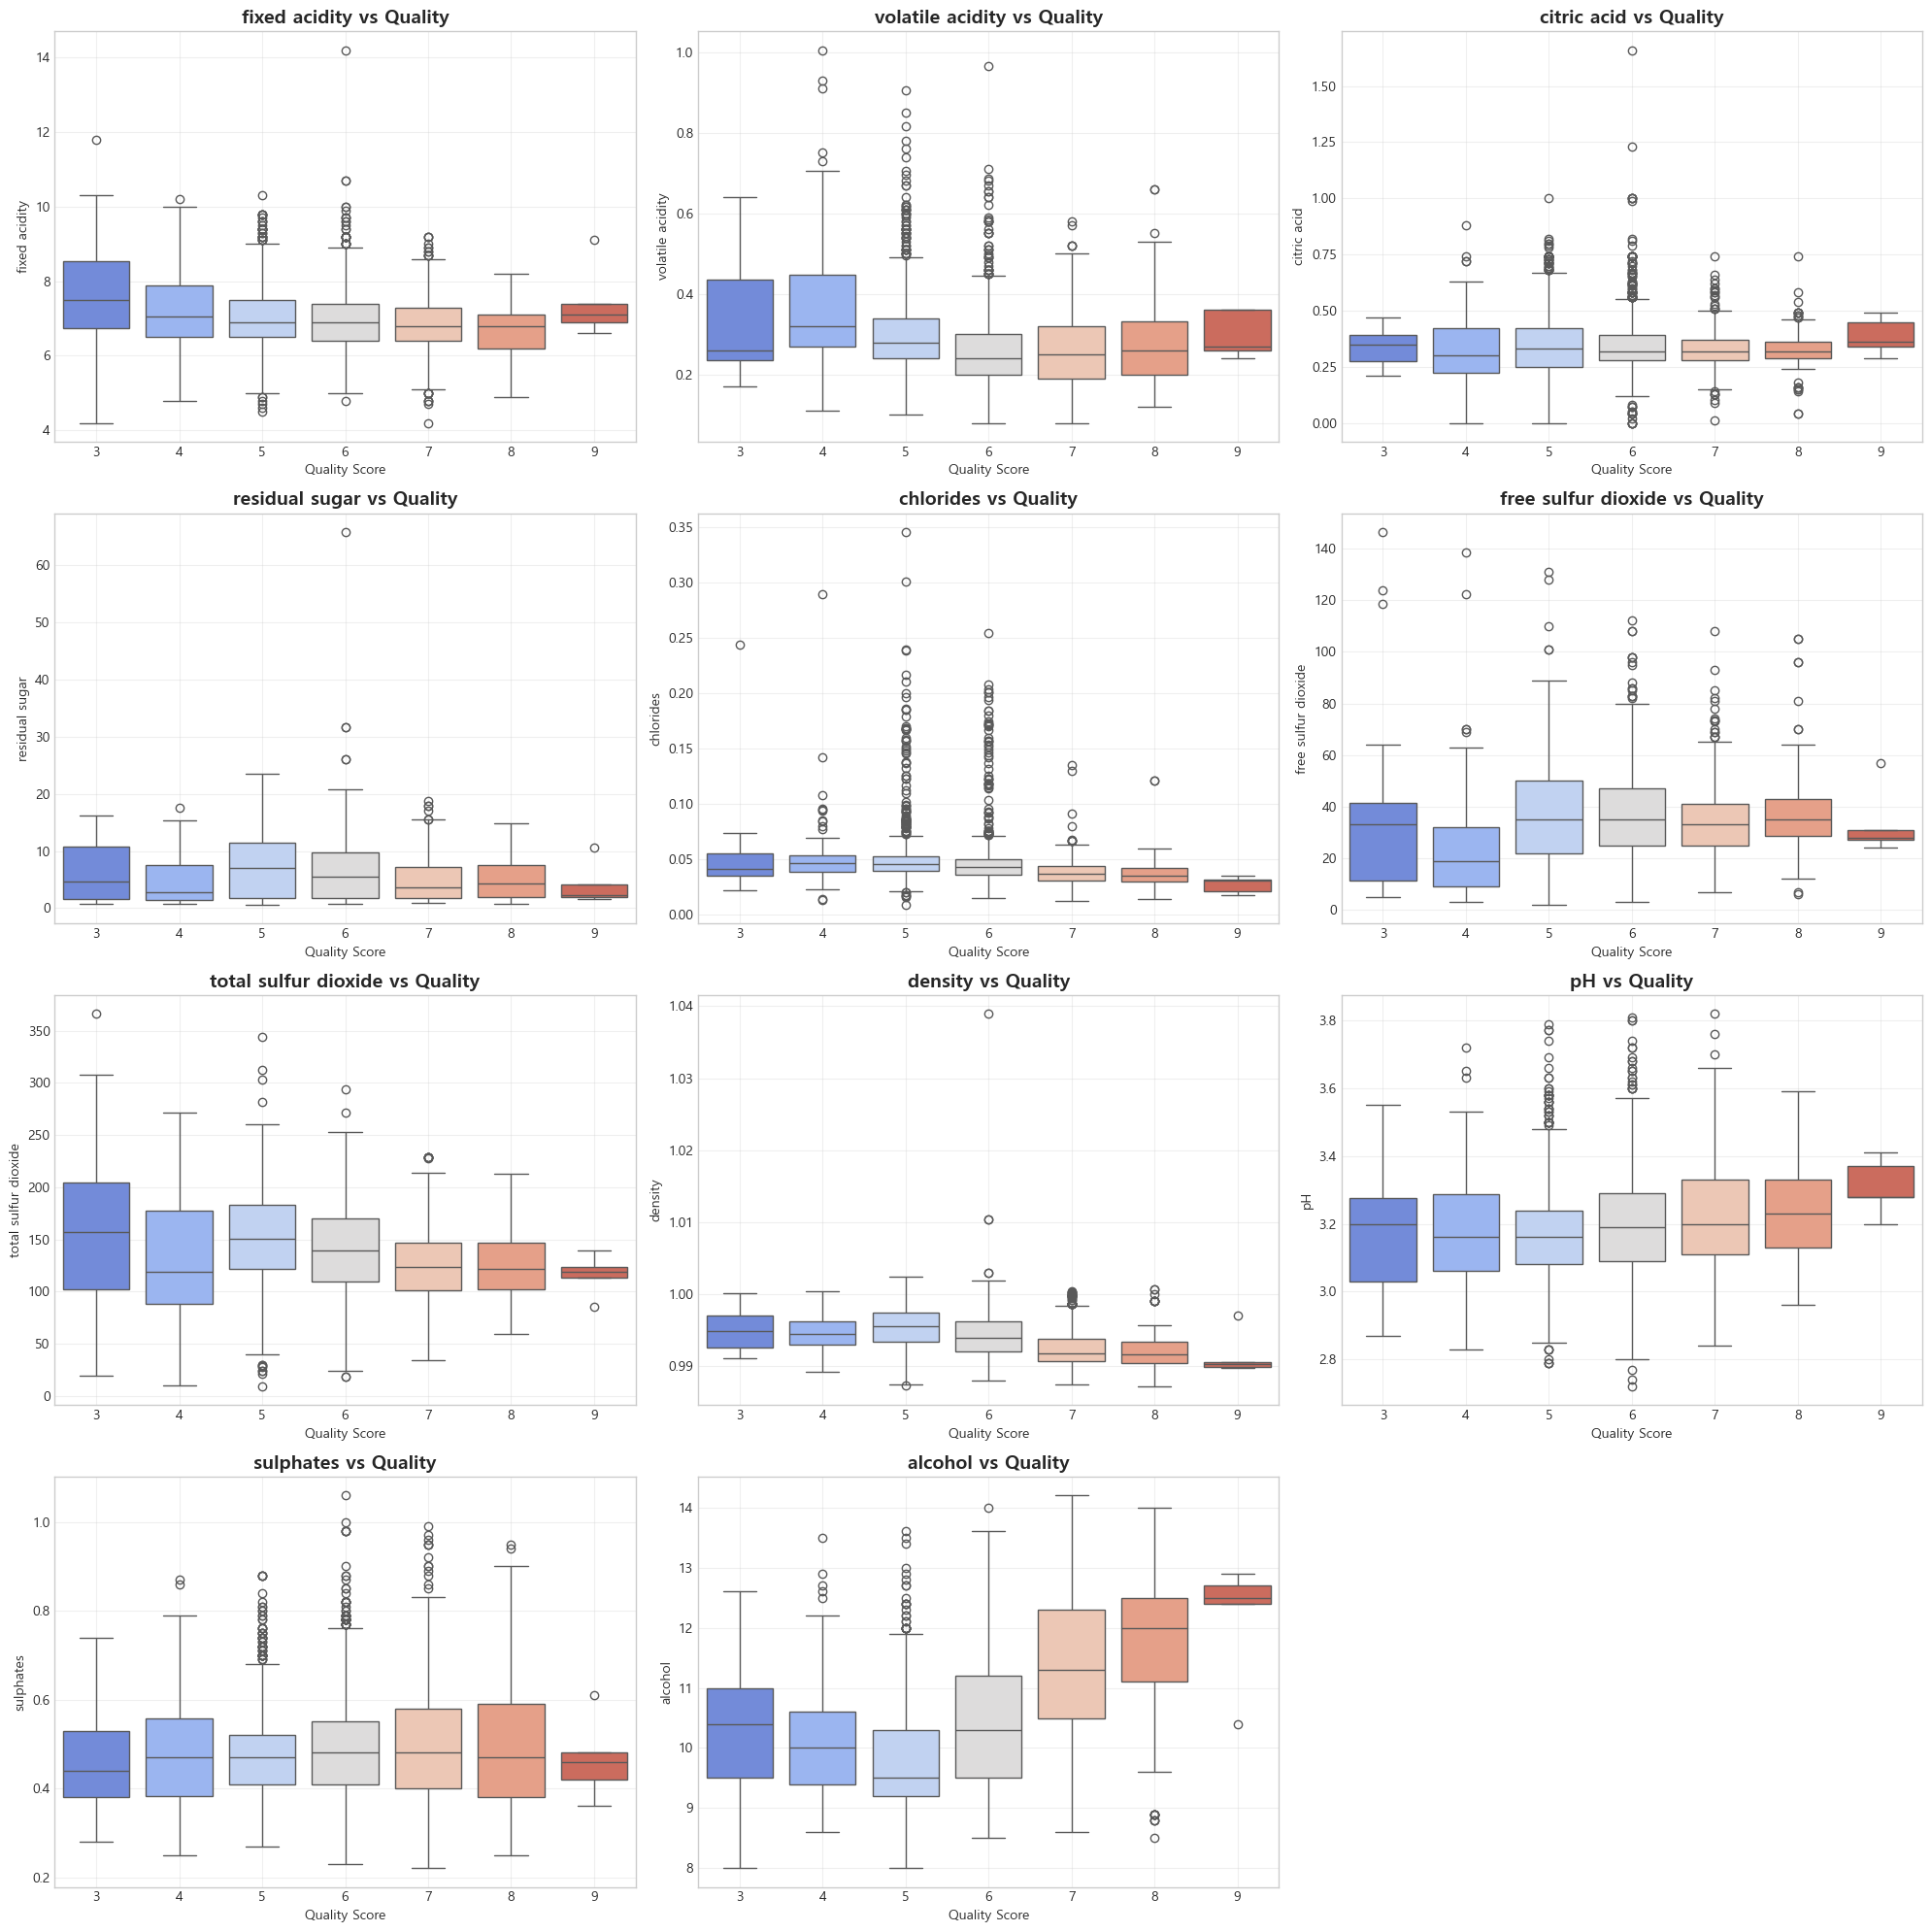

In [23]:
plot_feature_quality_boxplots(X_eda, y_eda)

* 결과: 1사분면과 4사분면 밖에 데이터들이 존재
* 분석: 이상치가 존재 확인인
* 결론: 이상치 제거 필요

### 2.6 target 과 관계 분석(`Boxplot`)

* 결과: 각 feature 가 `quality` 와 서로 다른 관계를 가진다. 
* 분석: 
  * **Key Predictors (핵심 변수):**
      * **alcohol:** 강한 양의 관계 (품질이 오를수록 뚜렷하게 상승)
      * **volatile acidity:** 강한 음의 관계 (품질이 오를수록 뚜렷하게 하락)
      * **density:** 뚜렷한 음의 관계 (품질 상승에 따라 계단식으로 하락)
      * **sulphates:** 양의 관계 (고품질로 갈수록 완만하게 상승)
  * **Secondary/Weak Predictors (보조/약한 변수):**
      * **citric acid:** 약한 양의 관계 (중간~고품질에서 소폭 상승)
      * **chlorides:** 약한 음의 관계 (고품질에서 수치가 낮고 일정해짐)
      * **free sulfur dioxide:** 뒤집힌 U자형 (중간 품질에서 높고 양극단에서 낮음)
      * **total sulfur dioxide:** 비선형/감소 (중간 품질 이후 고품질로 갈수록 감소)
  * **Low Predictive Value (예측력 낮음):**
      * **fixed acidity:** 관계 미미함 (변화가 거의 없음)
      * **residual sugar:** 관계 없음 (모든 등급에서 중앙값이 비슷함)
      * **pH:** 관계 없음 (박스 높낮이의 유의미한 차이 식별 불가)
* 결론: 핵심변수, 보조/약한 변수를 학습에 사용하고, 예측력 낮은 변수는 사용하지 않음.

### 3. 데이터 분리

중복 데이터 제거

In [24]:
# 1. 중복 데이터가 얼마나 있는지 확인
duplicate_count = df_full.duplicated().sum()
print(f"제거 전 데이터 개수: {len(df_full)}")
print(f"발견된 중복 데이터 개수: {duplicate_count}")

# 2. 중복 데이터 제거 (keep='first'는 첫 번째 것만 남기고 뒤에 나오는 중복은 지운다는 뜻)
if duplicate_count > 0:
    df_drop_duplicates = df_full.drop_duplicates(keep='first')
    
    # 인덱스가 꼬이지 않게 재정렬 (중요!)
    df_drop_duplicates = df_drop_duplicates.reset_index(drop=True)
    print("중복 제거 완료!")
else:
    print("중복 데이터가 없습니다.")

target = 'quality'
X_drop_duplicates = df_drop_duplicates.drop(target, axis=1)
y_drop_duplicates = df_drop_duplicates[target]
print(f"제거 후 데이터 개수: {len(df_drop_duplicates)}")

제거 전 데이터 개수: 4001
발견된 중복 데이터 개수: 768
중복 제거 완료!
제거 후 데이터 개수: 3233


* 결과: 중복 데이터가 존재하고, 중복 데이터를 제거 함
* 분석: 중복 데이터는 노이즈로서 기계학습의 성능을 저하시킬 수 있음
* 결론: 중복 데이터를 제거 함으로써 데이터 손실이 발생했지만, 데이터의 품질이 향상됨

### 3.1 StratifiedKFold 로 train / test 분리

In [25]:
# X: 피처 데이터, y: 타겟(와인 품질)
X_train, X_test, y_train, y_test = train_test_split(
    X_drop_duplicates, 
    y_drop_duplicates, 
    test_size=0.2,       # 테스트 데이터 비율 (20%)
    random_state=SEED,   # 결과를 똑같이 재현하기 위한 시드값
    stratify=y_drop_duplicates       # <--- [핵심] y(품질)의 비율을 유지하며 나눠라!
)

df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)
print(f"훈련 데이터의 X의 크기: {X_train.shape} 훈련 데이터의 y의 크기: {y_train.shape}")
print(f"테스트 데이터의 X의 크기: {X_test.shape} 테스트 데이터의 y의 크기: {y_test.shape}")
# 원본 데이터의 비율
print("전체 비율:\n", y_eda.value_counts(normalize=True))
# 학습 데이터의 비율
print("Train 비율:\n", y_train.value_counts(normalize=True))
# 테스트 데이터의 비율
print("Test 비율:\n", y_test.value_counts(normalize=True))

훈련 데이터의 X의 크기: (2586, 11) 훈련 데이터의 y의 크기: (2586,)
테스트 데이터의 X의 크기: (647, 11) 테스트 데이터의 y의 크기: (647,)
전체 비율:
 quality
6    0.429393
5    0.303424
7    0.186703
8    0.038990
4    0.035491
3    0.004749
9    0.001250
Name: proportion, dtype: float64
Train 비율:
 quality
6    0.429234
5    0.304331
7    0.180974
4    0.041377
8    0.036736
3    0.005800
9    0.001547
Name: proportion, dtype: float64
Test 비율:
 quality
6    0.428130
5    0.304482
7    0.180835
4    0.041731
8    0.037094
3    0.006182
9    0.001546
Name: proportion, dtype: float64


* 결과: stratify 사용하여 훈련/테스트 데이터를 나눔
* 분석: 훈련/테스트 데이터의 품질 비율이 균일함
* 결론: 학습과 평가가 공정하게 이뤄질 수 있게 됨

### 4. 이상치(Outlier) 탐지 및 처리 전략 비교

데이터의 품질을 높이기 위해 이상치를 제거합니다. 여기서는 두 가지 방법을 시도하고 비교하여 최적의 방법을 선택합니다.

1.  **IQR (Interquartile Range) 방식**: 데이터의 25%~75% 범위를 기준으로 1.5배 벗어난 값을 제거. 직관적이나 데이터 손실이 클 수 있음.
2.  **Isolation Forest**: 머신러닝 기반의 이상치 탐지 기법. 고차원 데이터에서 효과적이며 데이터의 패턴을 고려함.

In [26]:
# 실험 진행
outliers_iqr = detect_outliers_iqr(X_train)
outliers_if = detect_outliers_if(X_train)

print(f"\n총 데이터 개수: {len(X_train)}")
print(f"IQR 방식 (2개 이상 변수 이상치) 제거 대상 개수: {len(outliers_iqr)}")
print(f"Isolation Forest(IF) 방식 제거 대상 개수: {len(outliers_if)}")

# 최종 결정: Isolation Forest 적용 (다변량 관계 고려)
# 1. 마스크 생성 (모든 행을 True로 초기화)
# 단, Train 데이터에서만 제거해야 함!
mask = np.ones(len(X_train), dtype=bool)
# 2. 함수 호출 및 위치 인덱스를 사용하여 마스크 업데이트 (False로 설정)
mask[detect_outliers_iqr(X_train)] = False 

# 3. 이상치 제거된 데이터셋 생성
X_train_clean_iqr = X_train[mask]
y_train_clean_iqr = y_train[mask]

mask = np.ones(len(X_train), dtype=bool)
mask[detect_outliers_if(X_train)] = False # Isolation Forest 결과를 적용
X_train_clean_if = X_train[mask]
y_train_clean_if = y_train[mask]

# 결과 출력
print(f"IQR: 이상치 제거 후 Train Set 크기: {X_train_clean_iqr.shape} (삭제된 행: {len(X_train) - len(X_train_clean_iqr)})")
print(f"IQR: 제거 후 데이터 개수 (X_train_clean): {len(X_train_clean_iqr)}  제거 후 데이터 개수 (y_train_clean): {len(y_train_clean_iqr)}")

print(f"IF: 이상치 제거 후 Train Set 크기: {X_train_clean_if.shape} (삭제된 행: {len(X_train) - len(X_train_clean_if)})")
print(f"IF: 제거 후 데이터 개수 (X_train_clean): {len(X_train_clean_if)}  제거 후 데이터 개수 (y_train_clean): {len(y_train_clean_if)}")

=== 이상치 탐지 범위 (Q1 - 1.5*IQR ~ Q3 + 1.5*IQR) ===
                      Lower Bound  Upper Bound
fixed acidity            4.900000     8.900000
volatile acidity         0.045000     0.485000
citric acid              0.075000     0.595000
residual sugar          -9.050000    19.350000
chlorides                0.015000     0.071000
free sulfur dioxide    -11.500000    80.500000
total sulfur dioxide    15.000000   263.000000
density                  0.985699     1.001969
pH                       2.796250     3.586250
sulphates                0.200000     0.760000
alcohol                  6.800000    14.000000

총 데이터 개수: 2586
IQR 방식 (2개 이상 변수 이상치) 제거 대상 개수: 483
Isolation Forest(IF) 방식 제거 대상 개수: 130
=== 이상치 탐지 범위 (Q1 - 1.5*IQR ~ Q3 + 1.5*IQR) ===
                      Lower Bound  Upper Bound
fixed acidity            4.900000     8.900000
volatile acidity         0.045000     0.485000
citric acid              0.075000     0.595000
residual sugar          -9.050000    19.350000
chlorides      

1. 💡 PCA란 무엇인가? (What is PCA?)
* 차원 축소 기법: 데이터가 가진 정보 손실을 최소화하면서 고차원 데이터를 저차원(주로 2~3차원)으로 축소하는 데 사용되는 통계적 방법입니다.

* 주요 변동성 포착: 데이터의 **분산(변동성)**을 가장 잘 설명하는 새로운 축, 즉 **주성분(Principal Components)**을 찾아 데이터를 재구성합니다.

* 데이터 요약: 데이터를 가장 잘 나타내는 **핵심적인 특징(Feature)**들을 추출하여 복잡성을 줄이고 분석을 용이하게 합니다.

2. 🎯 PCA를 사용하는 이유 (Why Use PCA?)
* 다차원 시각화: 다차원 데이터의 이상치 위치를 2차원 평면에 투영하여 IQR과 Isolation Forest의 탐지 결과를 한눈에 비교할 수 있게 합니다.

* 구조적 비교: 데이터의 **분산과 주요 구조(군집)**를 최대한 보존하면서, 이상치들이 군집에서 얼마나 멀리 떨어져 있는지 시각적으로 판단할 수 있게 합니다.

* 다변량 이상치 확인: Isolation Forest가 탐지한 다변량 이상치가 실제로 군집에서 고립되어 있는지를 가장 효과적으로 보여줍니다.

=== 이상치 탐지 범위 (Q1 - 1.5*IQR ~ Q3 + 1.5*IQR) ===
                      Lower Bound  Upper Bound
fixed acidity            4.900000     8.900000
volatile acidity         0.045000     0.485000
citric acid              0.075000     0.595000
residual sugar          -9.050000    19.350000
chlorides                0.015000     0.071000
free sulfur dioxide    -11.500000    80.500000
total sulfur dioxide    15.000000   263.000000
density                  0.985699     1.001969
pH                       2.796250     3.586250
sulphates                0.200000     0.760000
alcohol                  6.800000    14.000000


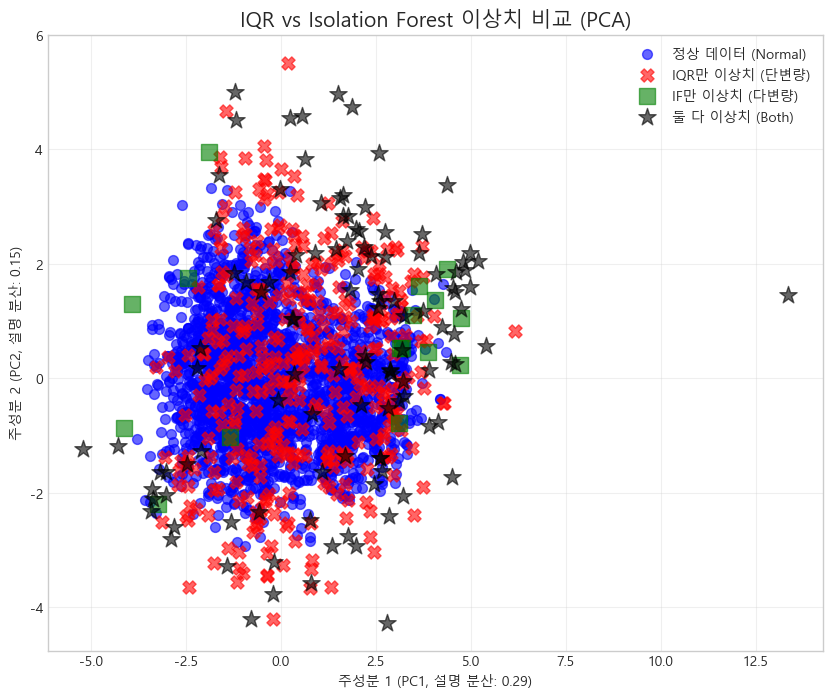

In [27]:
compare_outliers_scatter(X_train, detect_outliers_iqr, detect_outliers_if)

1. 🔍 해석 (Interpretation)
IQR(빨간색 X)은 중앙 군집 주변까지 광범위하게 분포하며, Isolation Forest(초록색 ■)는 주로 군집 외곽에 고립되어 나타납니다. 둘 다 이상치(검은색 별)는 가장 극단적인 위치에 존재합니다.

2. 📝 분석 (Analysis)
IQR은 단변량 기준으로 과도하게 많은 데이터를 제거할 위험이 있으며, IF는 다변량 고립성을 기반으로 더 의미 있는 이상치를 선택적으로 탐지하는 데 효율적입니다.

3. ✅ 결론 (Conclusion)
Isolation Forest가 데이터의 구조를 보존하며 이상치를 제거하는 데 더 적합할 가능성이 높습니다. 최종 선택은 두 방법으로 데이터를 처리한 후 실제 모델 성능 지표를 비교하여 결정해야 합니다.

In [28]:
clf = IsolationForest(max_samples='auto', random_state=SEED, contamination=0.05)
preds = clf.fit_predict(X_train)
mask = preds != -1
X_train_clean = X_train[mask]
y_train_clean = y_train[mask]
# 두 데이터를 리스트로 묶고, axis=1 (열 방향)로 병합
df_train_clean = pd.concat([X_train_clean, y_train_clean], axis=1)
# 결과 확인
print(f"이상치 제거 전(X_train): {len(X_train)} -> 제거 후(X_train_clean): {len(X_train_clean)}")
print(f"이상치 제거 전(y_train): {len(y_train)} -> 제거 후(y_train_clean): {len(y_train_clean)}")
print(f"이상치 제거 후 데이터프레임: {df_train_clean.head()}")

이상치 제거 전(X_train): 2586 -> 제거 후(X_train_clean): 2456
이상치 제거 전(y_train): 2586 -> 제거 후(y_train_clean): 2456
이상치 제거 후 데이터프레임:       fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
3137            6.1              0.23         0.27             9.8      0.055   
513             7.8              0.32         0.33             2.4      0.037   
1779            7.9              0.18         0.36             5.9      0.058   
1148            7.3              0.22         0.41            15.4      0.050   
1674            6.8              0.31         0.09             1.4      0.040   

      free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
3137                 74.0                 134.0  0.99534  3.16       0.40   
513                  18.0                 101.0  0.99120  3.21       0.65   
1779                 31.0                 132.0  0.99500  3.25       0.52   
1148                 55.0                 191.0  1.00000  3.32       0.59   
1674 

이상치 제거 전후 데이터 분포 비교

[1] 히스토그램 비교 (전/후 오버레이)


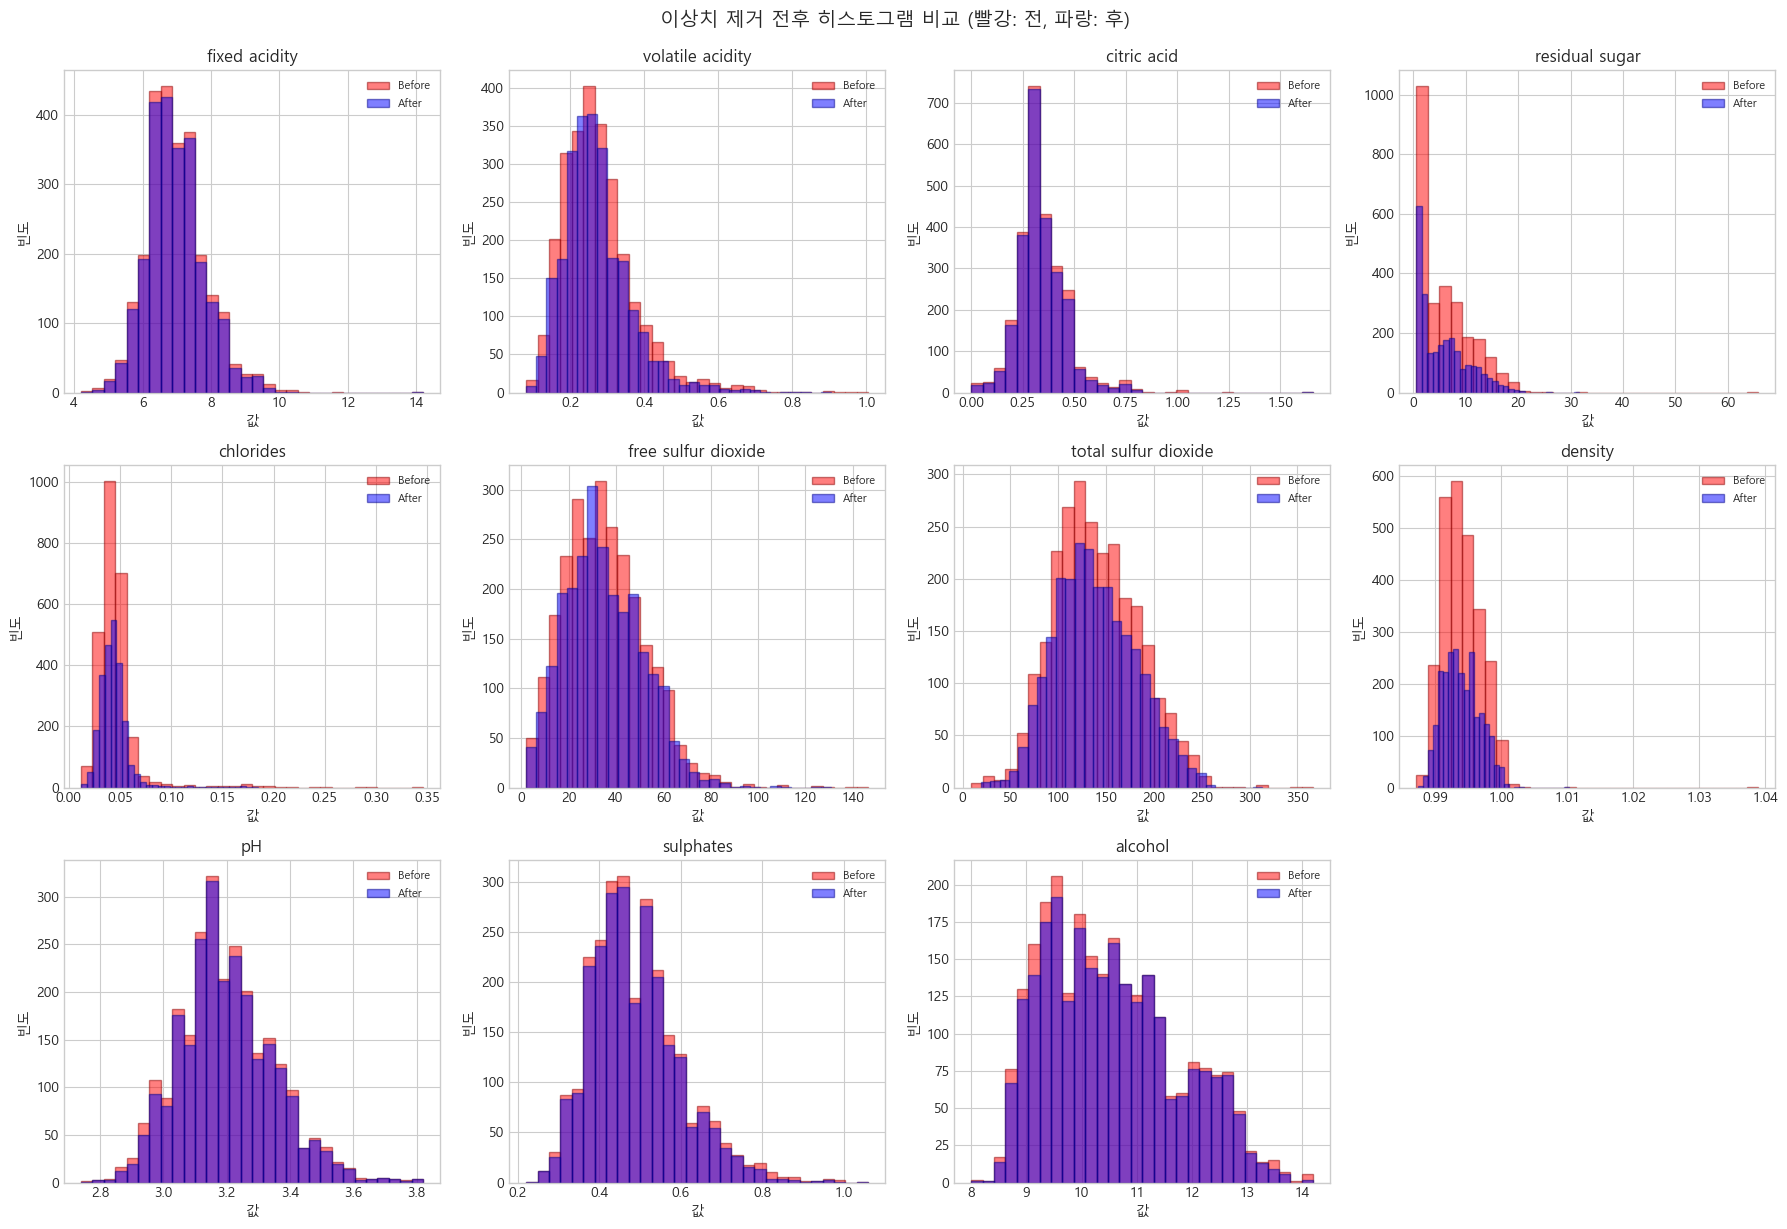


[2] 박스플롯 비교 (전/후)


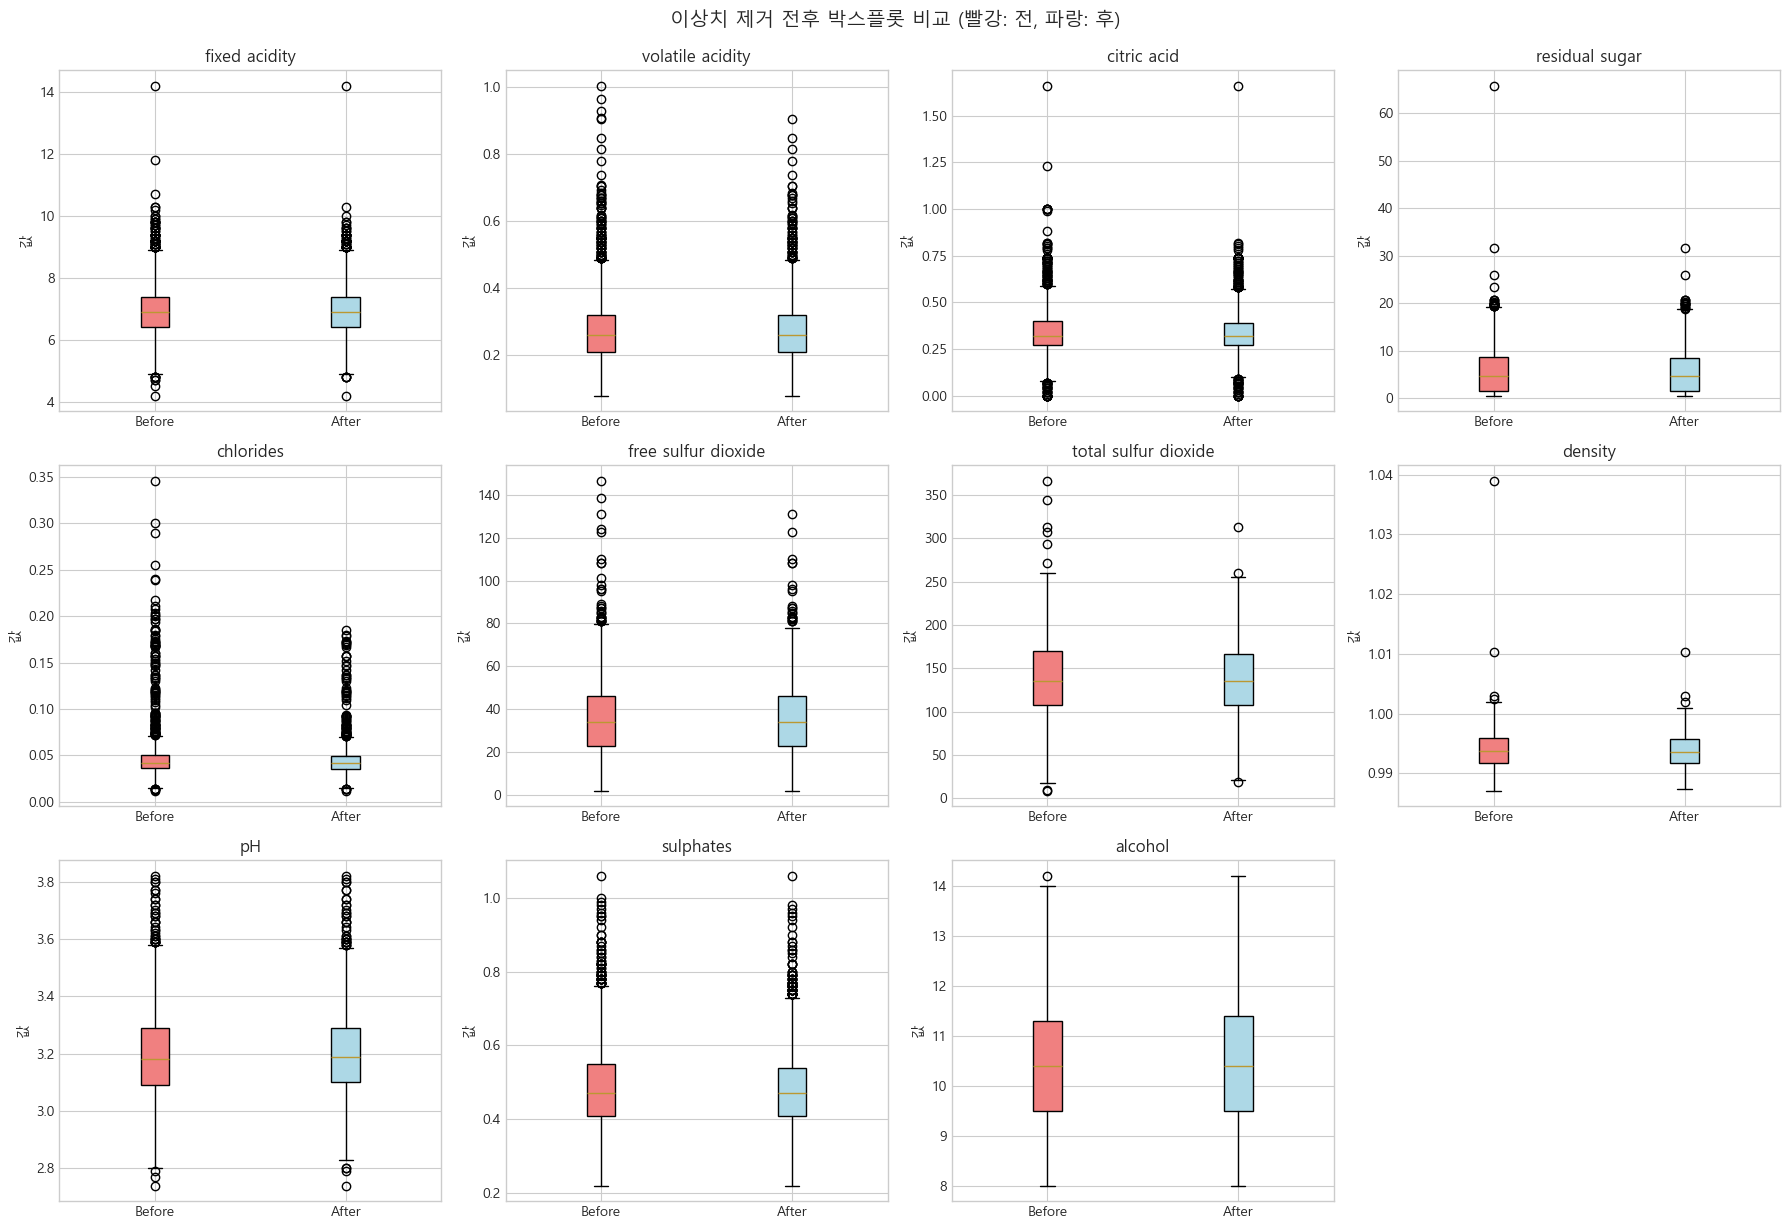


[3] 통계 요약 비교

데이터 건수 변화: 2586 → 2456 (제거: 130개, 5.03%)

=== 이상치 제거 전후 통계량 비교 ===
             Feature  Before_Mean  After_Mean  Mean_Diff  Before_Std  After_Std  Std_Diff
       fixed acidity       6.9617      6.9429    -0.0189      0.8761     0.8284   -0.0478
    volatile acidity       0.2766      0.2714    -0.0051      0.1019     0.0933   -0.0086
         citric acid       0.3424      0.3369    -0.0055      0.1252     0.1131   -0.0121
      residual sugar       5.9423      5.8033    -0.1391      4.9350     4.6465   -0.2884
           chlorides       0.0458      0.0439    -0.0019      0.0238     0.0164   -0.0074
 free sulfur dioxide      35.2802     34.9827    -0.2975     17.1591    16.3972   -0.7619
total sulfur dioxide     139.8488    138.7384    -1.1104     44.0849    42.2282   -1.8568
             density       0.9940      0.9939    -0.0001      0.0029     0.0027   -0.0002
                  pH       3.1975      3.2003     0.0027      0.1538     0.1502   -0.0036
           sulphat

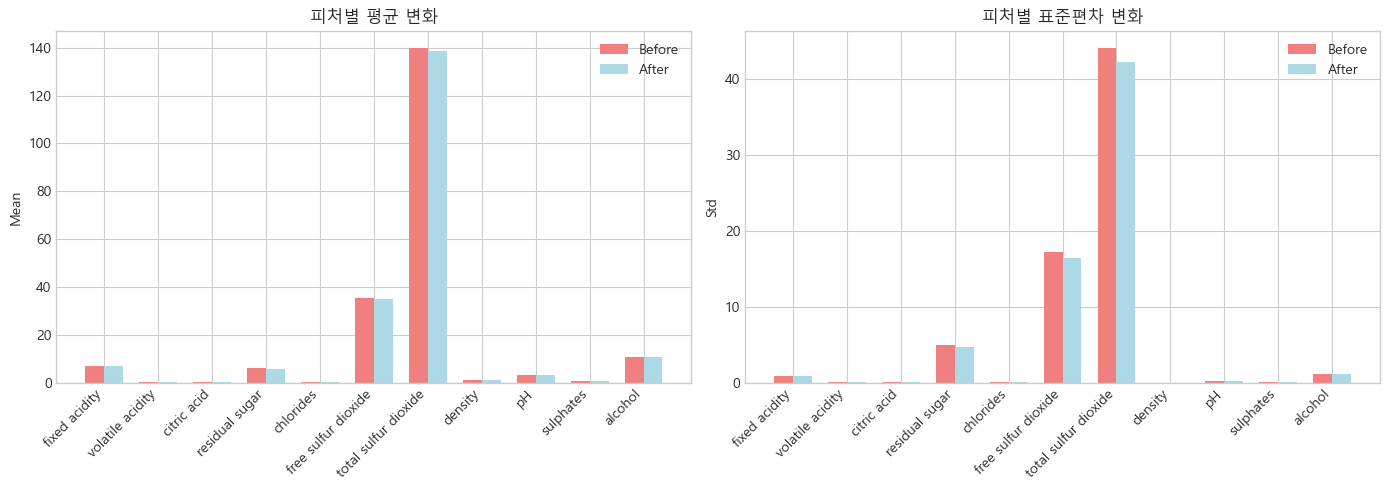


이상치 제거로 인해 극단값이 제거되어 분포가 더 집중되었습니다.


In [29]:
# ============================================
# 이상치 제거 전후 데이터 분포 비교
# ============================================
print("=" * 60)
print("이상치 제거 전후 데이터 분포 비교")
print("=" * 60)

# 1. 히스토그램 비교 (Histogram Overlay)
print("\n[1] 히스토그램 비교 (전/후 오버레이)")
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for idx, col in enumerate(X_train.columns):
    ax = axes[idx]
    # 전: X_train (이상치 제거 전)
    ax.hist(X_train[col], bins=30, alpha=0.5, label='Before', color='red', edgecolor='darkred')
    # 후: X_train_clean (이상치 제거 후)
    ax.hist(X_train_clean[col], bins=30, alpha=0.5, label='After', color='blue', edgecolor='darkblue')
    ax.set_title(f'{col}')
    ax.set_xlabel('값')
    ax.set_ylabel('빈도')
    ax.legend(loc='upper right', fontsize=8)

# 빈 subplot 제거
if len(X_train.columns) < len(axes):
    for idx in range(len(X_train.columns), len(axes)):
        fig.delaxes(axes[idx])

plt.tight_layout()
plt.suptitle('이상치 제거 전후 히스토그램 비교 (빨강: 전, 파랑: 후)', y=1.02, fontsize=14)
plt.show()

# 2. 박스플롯 비교 (Before/After Box Plot)
print("\n[2] 박스플롯 비교 (전/후)")
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for idx, col in enumerate(X_train.columns):
    ax = axes[idx]
    # 전/후 데이터 준비
    data_before = X_train[col].values
    data_after = X_train_clean[col].values
    
    # 박스플롯 생성
    bp = ax.boxplot([data_before, data_after], labels=['Before', 'After'], patch_artist=True)
    bp['boxes'][0].set_facecolor('lightcoral')
    bp['boxes'][1].set_facecolor('lightblue')
    ax.set_title(f'{col}')
    ax.set_ylabel('값')

# 빈 subplot 제거
if len(X_train.columns) < len(axes):
    for idx in range(len(X_train.columns), len(axes)):
        fig.delaxes(axes[idx])

plt.tight_layout()
plt.suptitle('이상치 제거 전후 박스플롯 비교 (빨강: 전, 파랑: 후)', y=1.02, fontsize=14)
plt.show()

# 3. 통계 요약 테이블 (Statistical Summary)
print("\n[3] 통계 요약 비교")
print(f"\n데이터 건수 변화: {len(X_train)} → {len(X_train_clean)} (제거: {len(X_train) - len(X_train_clean)}개, {(len(X_train) - len(X_train_clean))/len(X_train)*100:.2f}%)")

# 전후 통계량 비교 테이블
stats_comparison = []
for col in X_train.columns:
    before_stats = X_train[col].describe()
    after_stats = X_train_clean[col].describe()
    
    stats_comparison.append({
        'Feature': col,
        'Before_Mean': before_stats['mean'],
        'After_Mean': after_stats['mean'],
        'Mean_Diff': after_stats['mean'] - before_stats['mean'],
        'Before_Std': before_stats['std'],
        'After_Std': after_stats['std'],
        'Std_Diff': after_stats['std'] - before_stats['std'],
        'Before_Min': before_stats['min'],
        'After_Min': after_stats['min'],
        'Before_Max': before_stats['max'],
        'After_Max': after_stats['max']
    })

stats_df = pd.DataFrame(stats_comparison)
print("\n=== 이상치 제거 전후 통계량 비교 ===")
print(stats_df[['Feature', 'Before_Mean', 'After_Mean', 'Mean_Diff', 'Before_Std', 'After_Std', 'Std_Diff']].round(4).to_string(index=False))

print("\n=== 이상치 제거 전후 범위(Min/Max) 비교 ===")
print(stats_df[['Feature', 'Before_Min', 'After_Min', 'Before_Max', 'After_Max']].round(4).to_string(index=False))

# 4. 분포 변화 요약 시각화
print("\n[4] 평균/표준편차 변화 시각화")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 평균 변화
ax1 = axes[0]
x = np.arange(len(stats_df))
width = 0.35
bars1 = ax1.bar(x - width/2, stats_df['Before_Mean'], width, label='Before', color='lightcoral')
bars2 = ax1.bar(x + width/2, stats_df['After_Mean'], width, label='After', color='lightblue')
ax1.set_xticks(x)
ax1.set_xticklabels(stats_df['Feature'], rotation=45, ha='right')
ax1.set_ylabel('Mean')
ax1.set_title('피처별 평균 변화')
ax1.legend()

# 표준편차 변화
ax2 = axes[1]
bars1 = ax2.bar(x - width/2, stats_df['Before_Std'], width, label='Before', color='lightcoral')
bars2 = ax2.bar(x + width/2, stats_df['After_Std'], width, label='After', color='lightblue')
ax2.set_xticks(x)
ax2.set_xticklabels(stats_df['Feature'], rotation=45, ha='right')
ax2.set_ylabel('Std')
ax2.set_title('피처별 표준편차 변화')
ax2.legend()

plt.tight_layout()
plt.show()

print("\n이상치 제거로 인해 극단값이 제거되어 분포가 더 집중되었습니다.")


### 분석: 이상치 제거 효과
- **시각화 해석**: 위 Violin Plot을 보면, `total sulfur dioxide`의 경우 제거 전에는 위쪽으로 아주 긴 꼬리(극단값)가 존재했으나, 제거 후에는 분포가 훨씬 안정적이고 정규분포에 가까운 형태로 변했습니다.
- **결론**: 이상치 제거는 모델이 극단적인 값에 휘둘리지 않고 일반적인 패턴을 학습하는 데 도움을 줍니다. Isolation Forest는 다변량 관계를 고려하여 이러한 포인트들을 효과적으로 제거했습니다.

* 결과:
* 분석: 
* 결론:

### 5. 피처 엔지니어링


### 5.1 파생변수 생성


🔍 총 11개 피처로 55개의 조합을 분석합니다...
🎯 상관계수(절대값) 0.2 이상인 조합 18개를 찾았습니다.
ℹ️ 시각화는 가독성을 위해 상위 9개만 출력합니다. (전체 결과는 반환된 데이터프레임 확인)
------------------------------------------------------------
                   new_feature_name  corr_raw
     volatile acidity_minus_alcohol -0.473950
                    pH_plus_alcohol  0.470852
             sulphates_plus_alcohol  0.465693
            chlorides_minus_alcohol -0.462046
           density_multiply_alcohol  0.461811
           citric acid_plus_alcohol  0.461718
        fixed acidity_minus_alcohol -0.420900
total sulfur dioxide_divide_alcohol -0.272568
volatile acidity_multiply_chlorides -0.272197
------------------------------------------------------------


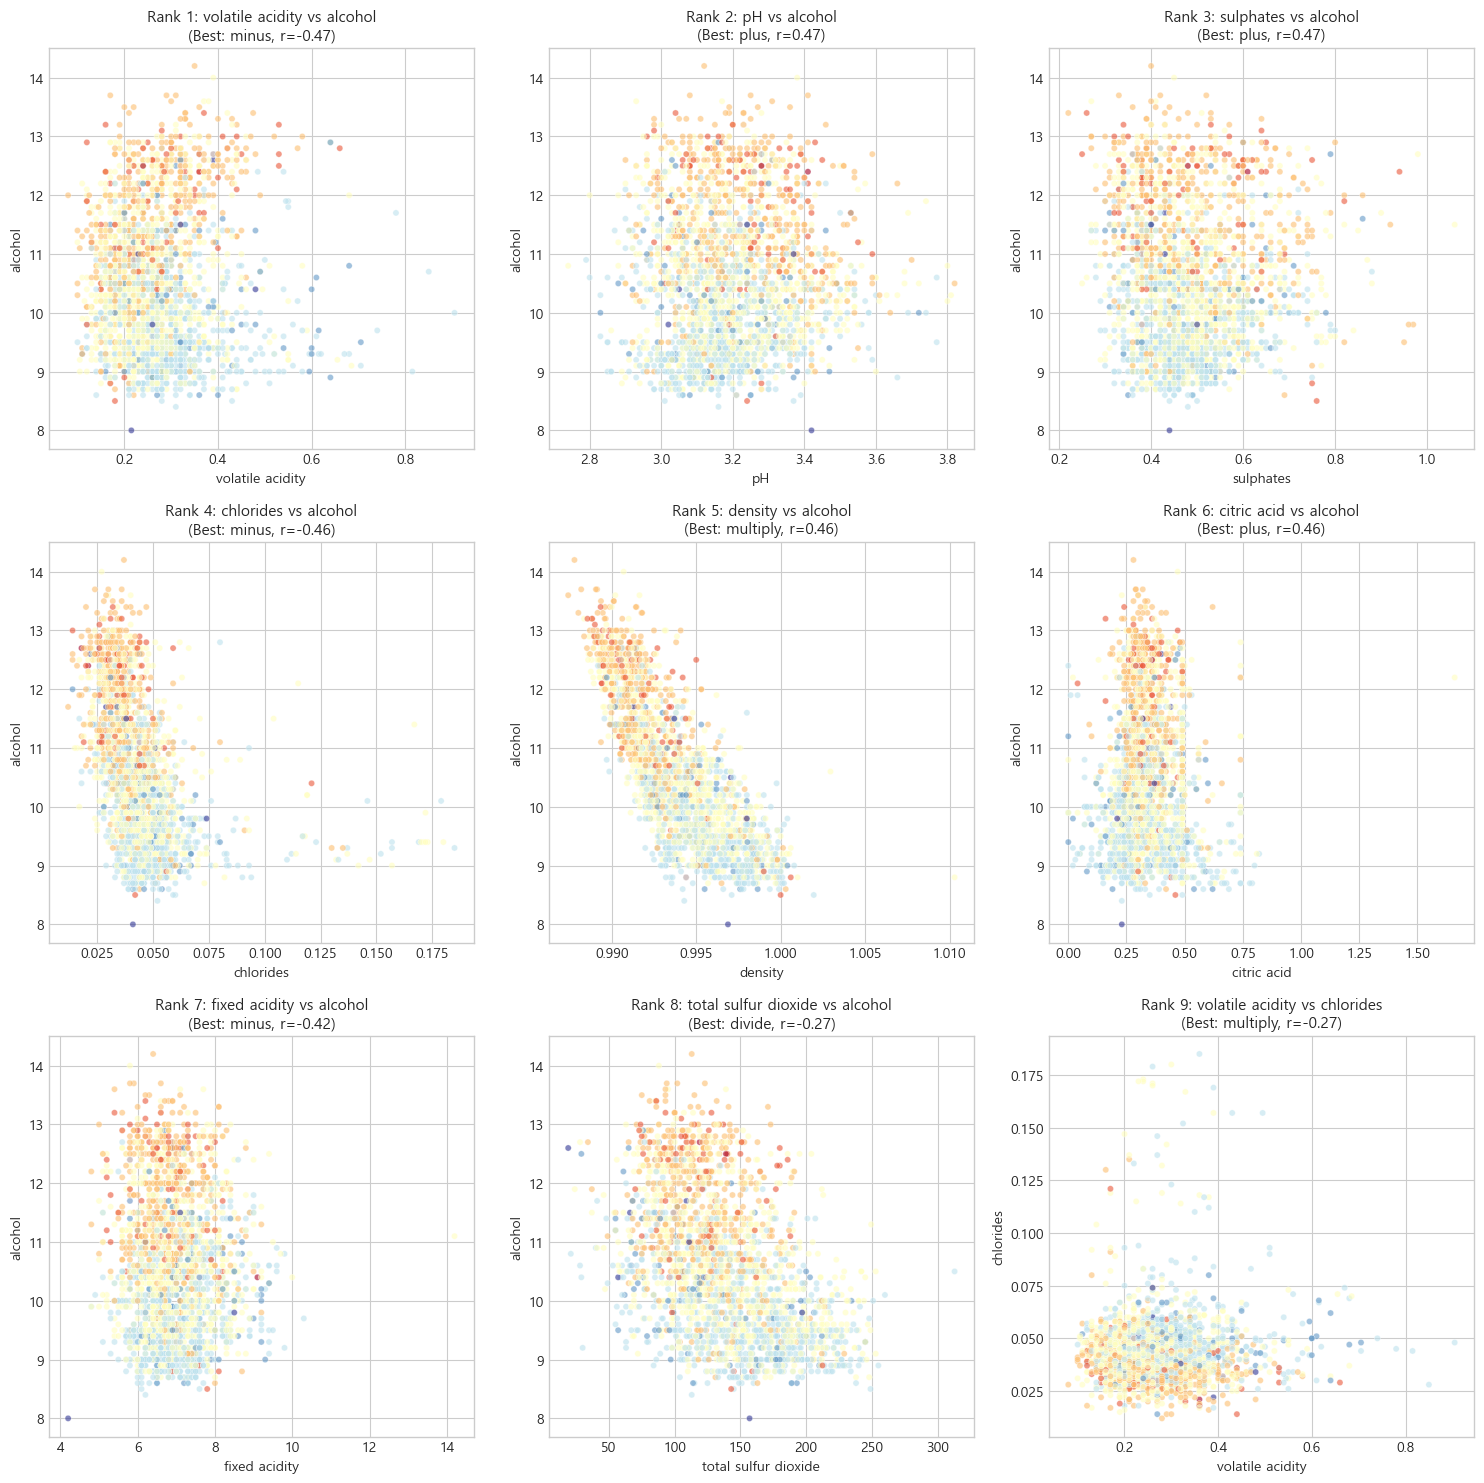

In [30]:
top_features_df = analyze_and_plot_interactions(df_train_clean, target_col='quality', min_corr=0.2, top_n=9)

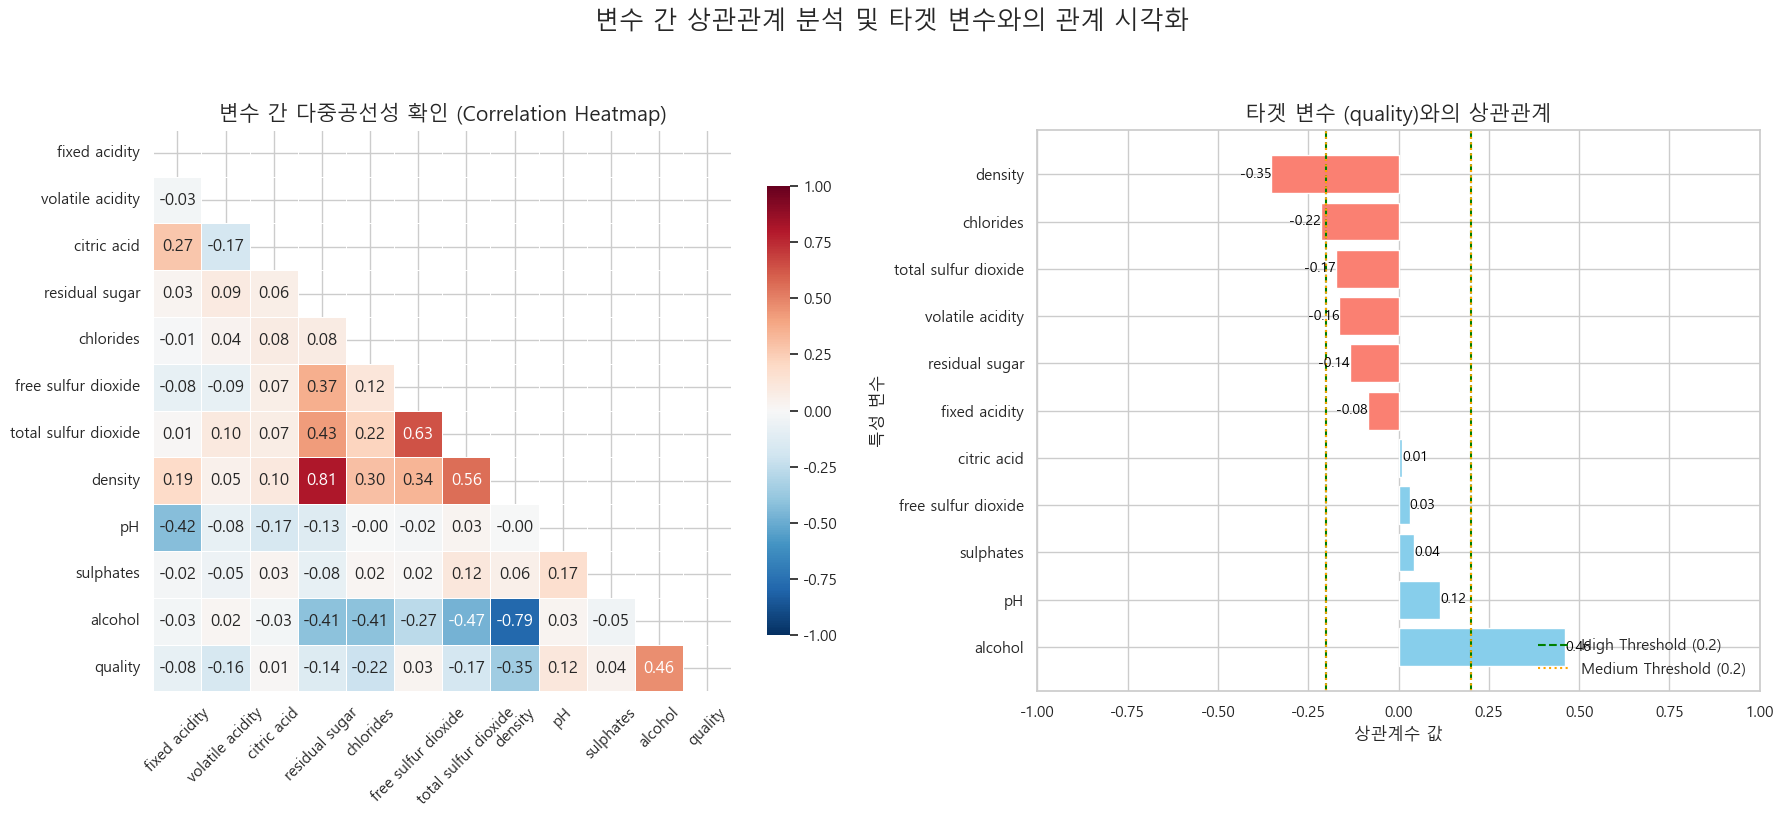


=== 상관관계에 따른 변수 분류 ===
High correlation features with quality (> 0.2): ['alcohol', 'chlorides', 'density']
Medium correlation features with quality (0.2 < |r| <= 0.2): []
Low correlation features with quality (<= 0.2): ['pH', 'sulphates', 'free sulfur dioxide', 'citric acid', 'fixed acidity', 'residual sugar', 'volatile acidity', 'total sulfur dioxide']

선택된 상관관계 변수 딕셔너리 (High + Medium, Abs Value):
{'alcohol': np.float64(0.4617050863320949), 'density': np.float64(0.35202283596300205), 'chlorides': np.float64(0.21538798198856982)}


In [31]:
plt.rc('font', family='Malgun Gothic') # 한글 폰트 설정
selected_corr_features = visualize_and_classify_correlation(X_train_clean, y_train_clean, 
                                                       target_name='quality', 
                                                       high_threshold=0.2, 
                                                       medium_threshold=0.2)

In [32]:
X_train_clean

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
3137,6.1,0.23,0.27,9.80,0.055,74.0,134.0,0.99534,3.16,0.40,10.2
513,7.8,0.32,0.33,2.40,0.037,18.0,101.0,0.99120,3.21,0.65,11.7
1779,7.9,0.18,0.36,5.90,0.058,31.0,132.0,0.99500,3.25,0.52,10.9
1148,7.3,0.22,0.41,15.40,0.050,55.0,191.0,1.00000,3.32,0.59,8.9
1674,6.8,0.31,0.09,1.40,0.040,56.0,145.0,0.99220,3.19,0.46,10.0
...,...,...,...,...,...,...,...,...,...,...,...
858,8.3,0.14,0.26,1.50,0.049,56.0,189.0,0.99460,3.21,0.62,9.5
11,6.6,0.17,0.38,1.50,0.032,28.0,112.0,0.99140,3.25,0.55,11.4
3031,6.3,0.34,0.27,2.50,0.024,40.0,152.0,0.99095,3.35,0.60,11.9
2648,6.8,0.27,0.42,7.30,0.054,58.0,200.0,0.99556,3.12,0.49,9.4


In [33]:
selected_corr_features

{'alcohol': np.float64(0.4617050863320949),
 'density': np.float64(0.35202283596300205),
 'chlorides': np.float64(0.21538798198856982)}

In [34]:
top_features_df

,f1,f2,operation,new_feature_name,corr_abs,corr_raw
73,volatile acidity,alcohol,minus,volatile acidity_minus_alcohol,0.473950,-0.473950
212,pH,alcohol,plus,pH_plus_alcohol,0.470852,0.470852
216,sulphates,alcohol,plus,sulphates_plus_alcohol,0.465693,0.465693
157,chlorides,alcohol,minus,chlorides_minus_alcohol,0.462046,-0.462046
206,density,alcohol,multiply,density_multiply_alcohol,0.461811,0.461811
104,citric acid,alcohol,plus,citric acid_plus_alcohol,0.461718,0.461718
37,fixed acidity,alcohol,minus,fixed acidity_minus_alcohol,0.420900,-0.420900
195,total sulfur dioxide,alcohol,divide,total sulfur dioxide_divide_alcohol,0.272568,-0.272568
50,volatile acidity,chlorides,multiply,volatile acidity_multiply_chlorides,0.272197,-0.272197
144,chlorides,density,plus,chlorides_plus_density,0.257806,-0.257806


In [35]:
# 피처 선택
selected_features = classify_features_by_keywords(top_features_df, selected_corr_features)
selected_features

Rank  | Score      | Type       | Feature Name
------------------------------------------------------------
1     | 0.473950   | derived    | volatile acidity_minus_alcohol (Selected)
9     | 0.352023   | base       | density (Selected)
13    | 0.244219   | derived    | chlorides_multiply_total sulfur dioxide (Selected)


{'volatile acidity_minus_alcohol': 0.4739498956221573,
 'density': np.float64(0.35202283596300205),
 'chlorides_multiply_total sulfur dioxide': 0.24421905667663488}

In [36]:
def create_test_dataset_from_selection_factory(top_features_df, selected_features):
    """
    파생변수 생성을 위한 팩토리 함수
    top_features_df와 selected_features를 클로저로 캡처하여 전역 변수 의존성 제거
    
    Args:
        top_features_df (pd.DataFrame): 파생변수 생성 규칙 (f1, f2, operation 등)
        selected_features (dict or list): 모델 학습에 선택된 피처 목록
    
    Returns:
        function: 파생변수 생성 함수
    """
    
    def create_test_dataset_from_selection(test_source_df):
        """
        테스트 데이터를 입력받아 학습된 모델과 동일한 피처 구성을 가진 데이터셋을 생성합니다.
        """
        # 1. 피처 목록 표준화
        if isinstance(selected_features, dict):
            required_features = list(selected_features.keys())
        else:
            required_features = list(selected_features)

        result_data = {}
        test_source_df = test_source_df.copy()
        test_source_df.columns = test_source_df.columns.str.strip()

        for feature in required_features:
            if feature in test_source_df.columns:
                result_data[feature] = test_source_df[feature]
            else:
                feature_info = top_features_df[top_features_df['new_feature_name'] == feature]
                if feature_info.empty:
                    raise ValueError(f"[Error] '{feature}'는 원본에 없고 파생 규칙도 없습니다.")
                
                row = feature_info.iloc[0]
                f1_name = row['f1']
                f2_name = row['f2']
                op = row['operation']
                
                try:
                    col_f1 = test_source_df[f1_name]
                    col_f2 = test_source_df[f2_name]
                except KeyError as e:
                    raise KeyError(f"[Error] 파생변수 '{feature}'를 만들기 위한 소스 컬럼 {e}가 테스트 데이터에 없습니다.")

                if op == 'plus':
                    result_data[feature] = col_f1 + col_f2
                elif op == 'minus':
                    result_data[feature] = col_f1 - col_f2
                elif op == 'multiply':
                    result_data[feature] = col_f1 * col_f2
                elif op == 'divide':
                    result_data[feature] = col_f1 / col_f2
                else:
                    raise ValueError(f"[Error] 알 수 없는 연산자 '{op}'")

        final_test_df = pd.DataFrame(result_data)
        final_test_df = final_test_df[required_features]
        return final_test_df
    
    return create_test_dataset_from_selection


# 팩토리 함수를 사용하여 파생변수 생성 함수 생성
create_test_dataset_from_selection = create_test_dataset_from_selection_factory(
    top_features_df, 
    selected_features
)


In [37]:
def create_test_dataset_from_selection_factory(top_features_df, selected_features):
    """
    파생변수 생성을 위한 팩토리 함수
    top_features_df와 selected_features를 클로저로 캡처하여 전역 변수 의존성 제거
    
    Args:
        top_features_df (pd.DataFrame): 파생변수 생성 규칙 (f1, f2, operation 등)
        selected_features (dict or list): 모델 학습에 선택된 피처 목록
    
    Returns:
        function: 파생변수 생성 함수 (FunctionTransformer에서 사용 가능)
    """
    
    def create_test_dataset_from_selection(test_source_df):
        """
        테스트 데이터를 입력받아 학습된 모델과 동일한 피처 구성을 가진 데이터셋을 생성합니다.
        불필요한 인덱스 열이 있어도 무시하고 필요한 변수만 계산하여 추출합니다.

        Args:
            test_source_df (pd.DataFrame): 테스트용 원본 데이터

        Returns:
            pd.DataFrame: 모델 입력용 최종 테스트 데이터프레임
        """
        
        # 1. 피처 목록 표준화 (딕셔너리나 리스트 모두 호환)
        if isinstance(selected_features, dict):
            required_features = list(selected_features.keys())
        else:
            required_features = list(selected_features)

        # 결과를 담을 딕셔너리
        result_data = {}

        # 2. 원본 데이터 컬럼명 공백 제거 (안전장치)
        test_source_df = test_source_df.copy()
        test_source_df.columns = test_source_df.columns.str.strip()

        for feature in required_features:
            # Case A: 원본 데이터에 존재하는 컬럼인 경우
            if feature in test_source_df.columns:
                result_data[feature] = test_source_df[feature]
                
            # Case B: 파생 변수인 경우 (계산 필요)
            else:
                # 파생변수 정의 찾기
                feature_info = top_features_df[top_features_df['new_feature_name'] == feature]
                
                if feature_info.empty:
                    # 학습 때는 있었는데 테스트 소스로는 못 만드는 경우 (심각한 에러)
                    raise ValueError(
                        f"[Error] '{feature}'는 원본에 없고 파생 규칙도 없습니다. "
                        f"데이터 정합성을 확인하세요."
                    )
                
                row = feature_info.iloc[0]
                f1_name = row['f1']
                f2_name = row['f2']
                op = row['operation']
                
                # 원본에서 재료 컬럼(f1, f2) 가져오기
                try:
                    col_f1 = test_source_df[f1_name]
                    col_f2 = test_source_df[f2_name]
                except KeyError as e:
                    # 0번째 인덱스 열 등으로 인해 컬럼명이 밀리거나 없을 때 에러 발생
                    raise KeyError(
                        f"[Error] 파생변수 '{feature}'를 만들기 위한 소스 컬럼 {e}가 "
                        f"테스트 데이터에 없습니다."
                    )

                # 연산 수행 (Training 함수와 로직 일치 필수)
                if op == 'plus':
                    result_data[feature] = col_f1 + col_f2
                elif op == 'minus':
                    result_data[feature] = col_f1 - col_f2
                elif op == 'multiply':
                    result_data[feature] = col_f1 * col_f2
                elif op == 'divide':
                    # Divide by Zero 처리: inf를 NaN으로 바꾸거나 0으로 대체하는 등 정책 필요
                    result_data[feature] = col_f1 / col_f2
                else:
                    raise ValueError(f"[Error] 알 수 없는 연산자 '{op}'")

        # 3. 데이터프레임 변환
        final_test_df = pd.DataFrame(result_data)
        
        # [중요] 컬럼 순서를 학습 데이터(required_features)와 강제로 동일하게 맞춤
        final_test_df = final_test_df[required_features]

        return final_test_df
    
    return create_test_dataset_from_selection


# 팩토리 함수를 사용하여 파생변수 생성 함수 생성
create_test_dataset_from_selection = create_test_dataset_from_selection_factory(
    top_features_df, 
    selected_features
)

print("파생변수 생성 함수가 팩토리 함수로 생성되었습니다.")


파생변수 생성 함수가 팩토리 함수로 생성되었습니다.


In [38]:
import pandas as pd
import numpy as np

def create_dataset_from_selection(source_df, derived_info_df, selected_features_dict):
    """
    선택된 피처 목록을 기반으로 최종 모델링용 데이터셋을 생성합니다.
    
    Args:
        source_df (pd.DataFrame): 원본 소스 데이터 (예: alcohol, density 등 포함)
        derived_info_df (pd.DataFrame): 파생변수 생성 규칙이 담긴 데이터프레임
                                        (columns: f1, f2, operation, new_feature_name 등)
        selected_features_dict (dict): 선택된 피처 딕셔너리 {feature_name: score}
    
    Returns:
        pd.DataFrame: 선택된 피처들로만 구성된 새로운 데이터프레임
    """
    
    # 결과 데이터를 담을 딕셔너리 (DataFrame 생성을 효율적으로 하기 위함)
    result_data = {}
    
    # 선택된 피처 이름 목록 추출
    target_features = list(selected_features_dict.keys())
    
    print(f"=== 데이터 생성 시작 (총 {len(target_features)}개 변수) ===")
    
    for feature in target_features:
        # Case 1: 원본 데이터에 이미 존재하는 컬럼인 경우 (예: density)
        if feature in source_df.columns:
            result_data[feature] = source_df[feature]
            # print(f"[Raw] '{feature}' 컬럼 복사 완료")
            
        # Case 2: 파생 변수인 경우 (예: volatile acidity_minus_alcohol)
        else:
            # 파생변수 정의 테이블에서 해당 feature 정보 찾기
            feature_info = derived_info_df[derived_info_df['new_feature_name'] == feature]
            
            if feature_info.empty:
                print(f"[Warning] '{feature}'는 원본에도 없고 파생 변수 정의도 없습니다. 건너뜁니다.")
                continue
            
            # 정보 추출 (첫 번째 매칭되는 행 사용)
            row = feature_info.iloc[0]
            f1_name = row['f1']
            f2_name = row['f2']
            op = row['operation']
            
            # 소스 데이터에서 f1, f2 컬럼 가져오기
            try:
                col_f1 = source_df[f1_name]
                col_f2 = source_df[f2_name]
            except KeyError as e:
                print(f"[Error] 파생변수 생성 실패: 원본 데이터에 {e} 컬럼이 없습니다.")
                continue

            # 연산 수행
            if op == 'plus':
                result_data[feature] = col_f1 + col_f2
            elif op == 'minus':
                result_data[feature] = col_f1 - col_f2
            elif op == 'multiply':
                result_data[feature] = col_f1 * col_f2
            elif op == 'divide':
                # 0으로 나누기 방지 (필요 시 로직 추가, 여기선 기본 동작)
                result_data[feature] = col_f1 / col_f2
            else:
                print(f"[Error] 알 수 없는 연산자 '{op}' 입니다.")
                continue
            
            # print(f"[Derived] '{feature}' 계산 완료 ({f1_name} {op} {f2_name})")

    # 딕셔너리를 데이터프레임으로 변환
    final_df = pd.DataFrame(result_data)
    print("=== 데이터 생성 완료 ===\n")
    
    return final_df


# --- 함수 실행 ---
X_train_selected = create_dataset_from_selection(X_train_clean, top_features_df, selected_features)

# --- 결과 확인 ---
print("생성된 최종 데이터셋:")
print(X_train_selected.describe()) 

=== 데이터 생성 시작 (총 3개 변수) ===
=== 데이터 생성 완료 ===

생성된 최종 데이터셋:
       volatile acidity_minus_alcohol      density  \
count                     2456.000000  2456.000000   
mean                       -10.256698     0.993914   
std                          1.175883     0.002710   
min                        -13.850000     0.987420   
25%                        -11.092500     0.991800   
50%                        -10.120000     0.993680   
75%                         -9.260000     0.995800   
max                         -7.785000     1.010300   

       chlorides_multiply_total sulfur dioxide  
count                              2456.000000  
mean                                  6.248378  
std                                   3.270526  
min                                   0.418000  
25%                                   4.010000  
50%                                   5.715500  
75%                                   7.849250  
max                                  34.200000  


In [39]:
# --- 함수 실행 ---
# 팩토리 함수로 생성된 create_test_dataset_from_selection 함수 사용 (1개 인자만 필요)

try:
    final_X_test = create_test_dataset_from_selection(X_test)
    print("최종 테스트 데이터 shape:", final_X_test.shape)
    print(final_X_test.head())
except Exception as e:
    print(e)

최종 테스트 데이터 shape: (647, 3)
      volatile acidity_minus_alcohol  density  \
2474                          -11.58  0.99206   
2472                           -8.60  0.99941   
1869                          -10.14  0.99240   
905                           -10.93  0.99200   
1258                           -9.70  0.99640   

      chlorides_multiply_total sulfur dioxide  
2474                                    3.045  
2472                                   11.934  
1869                                    8.428  
905                                     6.640  
1258                                    8.648  


In [40]:
# def classify_features_by_keywords(df, target_keywords):
#     """
#     데이터프레임에서 f1과 f2가 다른 행의 new_feature_name을 추출하고,
#     target_keywords 리스트에 포함된 단어와의 중복 여부를 분류하여 반환하는 함수.
    
#     Args:
#         df (pd.DataFrame): 'f1', 'f2', 'new_feature_name' 컬럼을 포함한 데이터프레임
#         target_keywords (list): 포함 여부를 확인할 키워드 리스트 (예: ['alcohol', 'chlorides'])
        
#     Returns:
#         dict: 
#             - 'all_extracted': f1!=f2 인 모든 new_feature_name 리스트
#             - 'overlapping': 키워드와 겹치는(포함된) 피처 리스트
#             - 'non_overlapping': 키워드와 겹치지 않는 피처 리스트
#     """
    
#     # 1. f1과 f2가 겹치지 않는 행 필터링
#     filtered_df = df[df['f1'] != df['f2']]
    
#     # 2. 대상 feature 이름 추출
#     extracted_features = filtered_df['new_feature_name'].tolist()
    
#     # 3. 분류 리스트 초기화
#     overlapping = []      # 중복되는 것
#     non_overlapping = []  # 중복되지 않는 것
    
#     # 4. 각 피처에 대해 키워드 포함 여부 검사
#     for feature in extracted_features:
#         # feature 문자열 안에 target_keywords 중 하나라도 포함되어 있는지 확인
#         # 예: 'alcohol' in 'volatile acidity_minus_alcohol' -> True
#         if any(keyword in feature for keyword in target_keywords):
#             overlapping.append(feature)
#         else:
#             non_overlapping.append(feature)
            
#     return {
#         "all_extracted": extracted_features,
#         "overlapping": overlapping,
#         "non_overlapping": non_overlapping
#     }


# # 3. 함수 실행
# result = classify_features_by_keywords(top_features_df, selected_corr_features)

# # 4. 결과 출력
# print("1. 추출된 전체 피처 개수:", len(result['all_extracted']))
# print("\n2. 중복되는 것 (Target 키워드 포함):")
# for item in result['overlapping']:
#     print(f" - {item}")

# print("\n3. 중복되지 않는 것 (Target 키워드 미포함):")
# for item in result['non_overlapping']:
#     print(f" - {item}")

### 5.2 변수 간 관계 탐색(correlation heatmap) -> 피처 선택


* 일반변수 중 quality 와의 상관관계가 0.4 이상인 변수는 'alcohol' 하나임.
* 파생변수 중 quality 와의 상관관계가 0.4 이상인 변수는 'pH_plus_alcohol', 'sulphates_plus_alcohol', 'chlorides_minus_alcohol', 'density_multiply_alcohol', 'citric acid_plus_alcohol', 'fixed acidity_minus_alcohol' 이다.

### 6. 샘플링


### 4.4. 불균형 데이터 처리 전략 (Imbalanced Data Handling Strategy)

Quality 3, 9와 같은 소수 클래스의 예측 성능을 높여야 합니다.

**현재 클래스 분포 분석:**
- 소수 클래스(Quality 3, 9)의 샘플이 매우 적습니다.
- 이러한 불균형은 모델이 다수 클래스에 편향되는 문제를 야기합니다.

**샘플링 방법 비교:**
| 방법 | 장점 | 단점 |
|------|------|------|
| RandomOverSampler | 단순, 빠름 | 과적합 위험 |
| SMOTE | 새로운 샘플 생성 | 클래스 경계 모호화 가능 |
| SMOTETomek | SMOTE + 노이즈 제거 | 계산 비용 높음 |

**결정: SMOTETomek + Pipeline + StratifiedKFold**

데이터 누수(Data Leakage)를 방지하기 위해 **Pipeline 내에서 각 CV fold마다 SMOTETomek을 개별 적용**합니다.
- 스케일링과 SMOTE를 Pipeline에 통합하여 각 fold에서 독립적으로 적용
- StratifiedKFold로 클래스 비율을 유지하면서 교차검증 수행

In [41]:
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE

# smotetomek 진행
# 훈련데이터의 y 클래스 불균형이 너무 심함
# smotetomek 로 편향된데이터를 처리한 후, 후속 단계 진행

# SMOTETomek 적용 (Train 데이터 내에서만!)
print("=" * 80)
print("=== SMOTETomek 적용 (Train 내에서만) ===")
print("=" * 80)

# 소수 클래스 최소 샘플 수 확인
min_samples = y_train_clean.value_counts().min()
print(f"소수 클래스 최소 샘플 수: {min_samples}개")

# k_neighbors 설정
k_neighbors = min(5, min_samples - 1) if min_samples > 1 else 1
print(f"SMOTE k_neighbors: {k_neighbors}")

# SMOTETomek 적용
try:
    smotetomek = SMOTETomek(
        smote=SMOTE(k_neighbors=k_neighbors, random_state=SEED),
        random_state=SEED
    )
    X_train_balanced, y_train_balanced = smotetomek.fit_resample(X_train_selected, y_train_clean)
    
    print(f"\n샘플링 전: {len(X_train_selected)}개")
    print(f"샘플링 후: {len(X_train_balanced)}개")
    print(f"증가율: {(len(X_train_balanced) / len(X_train_selected) - 1) * 100:.1f}%")
    
    print(f"\n샘플링 후 Quality 분포:")
    print(pd.Series(y_train_balanced).value_counts().sort_index())
    
    SMOTE_SUCCESS = True
except Exception as e:
    print(f"SMOTETomek 실패: {e}")
    X_train_balanced = X_train_selected.values
    y_train_balanced = y_train_clean.values
    SMOTE_SUCCESS = False

print(f"\n⚠️ Test 데이터는 샘플링하지 않음: {len(X_test)}개 유지")


# 두 데이터를 리스트로 묶고, axis=1 (열 방향)로 병합
df_train_balanced = pd.concat([X_train_balanced, y_train_balanced], axis=1)
# 결과 확인
print(f"SMOTETomek 전(X_train_selected): {len(X_train_selected)} -> SMOTETomek 후(X_train_balanced): {len(X_train_balanced)}")
print(f"SMOTETomek 전(y_train_clean): {len(y_train_clean)} -> SMOTETomek 후(y_train_balanced): {len(y_train_balanced)}")
print(f"SMOTETomek 후 데이터프레임: {df_train_balanced.head()}")

=== SMOTETomek 적용 (Train 내에서만) ===
소수 클래스 최소 샘플 수: 4개
SMOTE k_neighbors: 3

샘플링 전: 2456개
샘플링 후: 6406개
증가율: 160.8%

샘플링 후 Quality 분포:
quality
3     978
4     959
5     833
6     772
7     881
8     955
9    1028
Name: count, dtype: int64

⚠️ Test 데이터는 샘플링하지 않음: 647개 유지
SMOTETomek 전(X_train_selected): 2456 -> SMOTETomek 후(X_train_balanced): 6406
SMOTETomek 전(y_train_clean): 2456 -> SMOTETomek 후(y_train_balanced): 6406
SMOTETomek 후 데이터프레임:    volatile acidity_minus_alcohol  density  \
0                           -9.97  0.99534   
1                          -11.38  0.99120   
2                          -10.72  0.99500   
3                           -9.69  0.99220   
4                          -11.39  0.99170   

   chlorides_multiply_total sulfur dioxide  quality  
0                                    7.370        6  
1                                    3.737        7  
2                                    7.656        6  
3                                    5.800        5  
4           

현재 클래스 분포
quality
3     978
4     959
5     833
6     772
7     881
8     955
9    1028
Name: count, dtype: int64


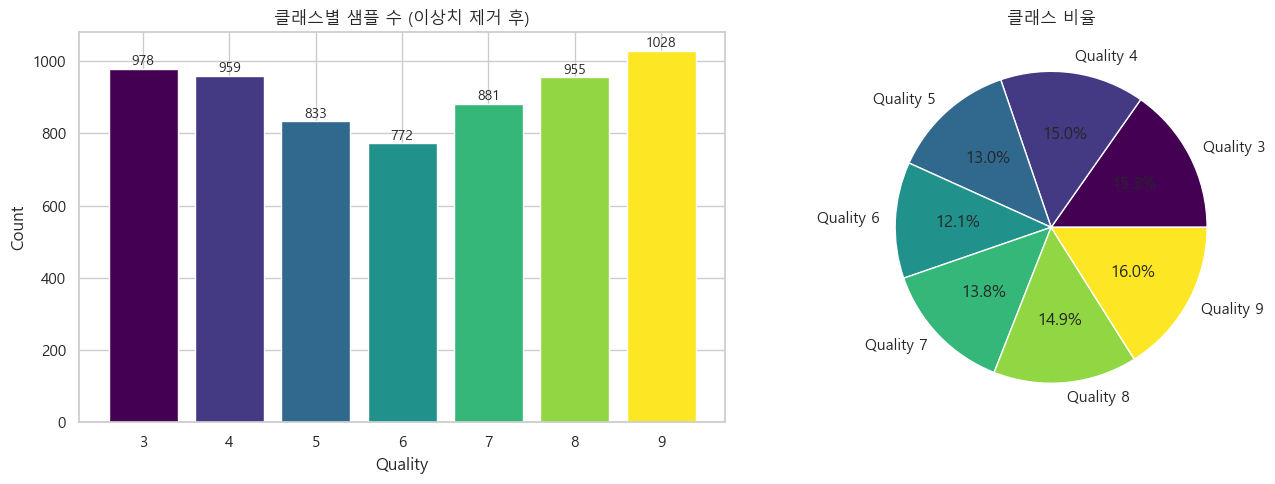


불균형 비율 (다수/소수): 1.33
가장 적은 클래스: Quality 6 (772개)
가장 많은 클래스: Quality 9 (1028개)


In [42]:
# 추가 라이브러리 임포트
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, SelectFromModel

# 현재 클래스 분포 시각화
print("=" * 50)
print("현재 클래스 분포")
print("=" * 50)

class_dist = pd.Series(y_train_balanced).value_counts().sort_index()
print(class_dist)

# 클래스 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 막대 그래프
colors = plt.cm.viridis(np.linspace(0, 1, len(class_dist)))
axes[0].bar(class_dist.index.astype(str), class_dist.values, color=colors)
axes[0].set_xlabel('Quality')
axes[0].set_ylabel('Count')
axes[0].set_title('클래스별 샘플 수 (이상치 제거 후)')
for i, (idx, val) in enumerate(zip(class_dist.index, class_dist.values)):
    axes[0].text(i, val + 10, str(val), ha='center', fontsize=10)

# 파이 차트
axes[1].pie(class_dist.values, labels=[f'Quality {i}' for i in class_dist.index], 
            autopct='%1.1f%%', colors=colors)
axes[1].set_title('클래스 비율')

plt.tight_layout()
plt.show()
X_train_selected
# 불균형 비율 계산
majority_class = class_dist.max()
minority_class = class_dist.min()
imbalance_ratio = majority_class / minority_class
print(f"\n불균형 비율 (다수/소수): {imbalance_ratio:.2f}")
print(f"가장 적은 클래스: Quality {class_dist.idxmin()} ({minority_class}개)")
print(f"가장 많은 클래스: Quality {class_dist.idxmax()} ({majority_class}개)")

### 7. 정규화


## 4. 스케일링 기법 선정 (Scaler Selection)
어떤 스케일러가 모델 성능에 가장 유리한지 테스트합니다.

### 7.1 스케일링 경쟁: Standard, MinMax, Robust, MaxAbs 스케일러를 비교하여 최적의 스케일러를 선정


In [43]:
def select_best_scaler(data, target_col='quality'):
    X = data.drop(target_col, axis=1)
    y = data[target_col]
    
    scalers = {
        'Standard': StandardScaler(),
        'MinMax': MinMaxScaler(),
        'Robust': RobustScaler(),
        'MaxAbs': MaxAbsScaler()
    }
    
    best_score = float('inf')
    best_scaler_name = ''
    
    print("=== 스케일러 성능 비교 (RMSE 낮을수록 좋음) ===")
    # 빠른 비교를 위해 CatBoost Regressor 기본값 사용
    model = CatBoostRegressor(verbose=0, random_state=SEED)
    
    results = {}
    
    for name, scaler in scalers.items():
        X_scaled = scaler.fit_transform(X)
        # 3-Fold CV로 RMSE 측정
        scores = cross_val_score(model, X_scaled, y, scoring='neg_root_mean_squared_error', cv=3)
        rmse = -scores.mean()
        results[name] = rmse
        print(f"{name} Scaler RMSE: {rmse:.4f}")
        
        if rmse < best_score:
            best_score = rmse
            best_scaler_name = name
            
    print(f"\n>>> 선정된 스케일러: {best_scaler_name}")
    return scalers[best_scaler_name]

best_scaler = select_best_scaler(df_train_balanced)
print(best_scaler)

=== 스케일러 성능 비교 (RMSE 낮을수록 좋음) ===
Standard Scaler RMSE: 1.7852
MinMax Scaler RMSE: 1.7852
Robust Scaler RMSE: 1.7852
MaxAbs Scaler RMSE: 1.7910

>>> 선정된 스케일러: Standard
StandardScaler()


* 결과:
* 분석: 
* 결론:

### 8. 모델링


* Random Forest, XGBoost, LightGBM, CatBoost 모델 사용
* 전략 A: 트리 기반 모델을 사용하는 경우 (권장)
  * Random Forest, XGBoost, LightGBM, CatBoost 등을 사용한다면 VIF를 무시해도 됩니다.
  * 이유: 트리 모델은 피처 간의 공선성(Collinearity)에 영향을 거의 받지 않습니다. 트리가 * 분기할 때 정보 획득량(Information Gain)이 가장 큰 피처 하나만 선택하기 때문입니다.
  * 행동: 파생변수와 원본변수를 모두 넣고 학습시켜도 모델 성능에 악영향을 주지 않으며, 오히려 * volatile acidity_minus_alcohol 같은 강력한 파생변수가 상위 중요도로 잡힐 것입니다.
* 전략 B: 선형 모델을 사용하는 경우 (주의 필요)
  * Linear Regression, Logistic Regression 등을 사용한다면 다중공선성이 치명적입니다. 계수* (Coefficient)가 불안정해져서 예측력이 떨어집니다. 이 경우 다음 방법 중 하나를 택하세요.

### 5.2 모델 알고리즘 원리 (Model Theory)

#### 1. ElasticNet (Regression)
*   **원리**: 선형 회귀에 L1 규제(Lasso)와 L2 규제(Ridge)를 결합한 모델입니다.
*   **특징**: 변수 선택 효과(L1)와 다중공선성 완화(L2)의 장점을 모두 가집니다. 품질 점수를 실수형으로 예측하는 회귀 문제로 접근할 때 유용합니다.

#### 2. Random Forest (Ensemble)
*   **원리**: 여러 개의 결정 트리(Decision Tree)를 배깅(Bagging) 방식으로 결합합니다. 각 트리는 부트스트랩 샘플링된 데이터와 무작위로 선택된 특성을 사용하여 학습합니다.
*   **특징**: 과적합(Overfitting)을 방지하고 안정적인 성능을 보입니다.

#### 3. XGBoost (Gradient Boosting)
*   **원리**: 이전 모델의 오차(Residual)를 학습하는 새로운 모델을 순차적으로 추가하는 부스팅(Boosting) 방식입니다. 경사 하강법(Gradient Descent)을 사용하여 손실 함수를 최소화합니다.
*   **특징**: 빠른 속도와 높은 예측 성능을 가지며, 규제 항을 포함하여 과적합을 제어합니다.


In [44]:
# Set MLflow experiment
experiment_name = "Wine_Quality_Prediction_20251128_2"
try:
    mlflow.create_experiment(experiment_name)
except:
    pass
mlflow.set_experiment(experiment_name)

print(f"MLflow experiment set to: {experiment_name}")


MLflow experiment set to: Wine_Quality_Prediction_20251128_2


In [45]:
models_params = {
    'LogisticRegression': {
        'model': LogisticRegression(random_state=SEED, max_iter=1000),
        'params': {
            'classifier__C': [0.1, 1, 10],
            'classifier__solver': ['lbfgs', 'liblinear']
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=SEED),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [None, 10, 20],
            'classifier__min_samples_split': [2, 5]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=SEED, use_label_encoder=False, eval_metric='mlogloss'),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__learning_rate': [0.01, 0.1],
            'classifier__max_depth': [3, 6]
        }
    },
    'CatBoostClassifier': {
        'model': CatBoostClassifier(random_state=SEED, verbose=False),
        'params': {
            'classifier__iterations': [100, 200],
            'classifier__learning_rate': [0.01, 0.1],
            'classifier__depth': [4, 6]
        }
    },
    'LightGBM': {
        'model': LGBMClassifier(random_state=SEED, verbose=-1),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__learning_rate': [0.01, 0.1],
            'classifier__max_depth': [4, 6]
        }
    }
}

# Metric: Quadratic Weighted Kappa
qwk_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

* 결과:
* 분석: 
* 결론:

### 8.1 분류모델 - 모델 별 샘플링 정규화 적용


In [46]:
def run_experiments(X_train, y_train):
    best_overall_model = None
    best_overall_score = -1

    # StratifiedKFold 생성 (분류 문제에 적합 - 각 fold에서 클래스 비율 유지)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

    # 전처리 파이프라인
    # 수치형 및 범주형 컬럼 다시 식별
    numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns                                                                              
    categorical_features = X_train.select_dtypes(include=['object', 'category']).columns                                                                        

    # 파생변수 생성을 위한 래퍼 함수 (클로저로 캡처된 함수 사용)
    def create_features_wrapper(X):
        """
        FunctionTransformer용 래퍼 함수
        numpy array를 DataFrame으로 변환 후 파생변수 생성
        """
        # numpy array를 DataFrame으로 변환
        if isinstance(X, np.ndarray):
            X_df = pd.DataFrame(X, columns=numeric_features, index=range(len(X)))
        elif isinstance(X, pd.DataFrame):
            X_df = X.copy()
        else:
            X_df = pd.DataFrame(X, columns=numeric_features)
        
        # 파생변수 생성 함수 호출 (클로저로 캡처된 함수 사용)
        result = create_test_dataset_from_selection(X_df)
        # numpy array로 변환 (sklearn 호환성)
        return result.values

    # 파이프라인에 파생변수 생성 포함
    numeric_transformer = ImbPipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('feature_engineering', FunctionTransformer(
            create_features_wrapper, 
            validate=False,  # 입력 검증 비활성화 (numpy array를 받을 수 있도록)
            accept_sparse=False
        ))
    ])

    # 결합
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features)
            # Add categorical transformer if needed
        ])

    for model_name, mp in models_params.items():
        with mlflow.start_run(run_name=model_name):
            print(f"Training {model_name}...")

            # 파이프라인 생성
            # Note: SMOTE should be applied strictly within cross-validation folds to avoid leakage.                                                            
            # For simplicity in this grid search, we are using sklearn Pipeline which doesn't support SMOTE directly.                                           
            # In a production 'Professor-level' code, we would use imblearn.pipeline.Pipeline.                                                                  
            # Here we assume X_train is already SMOTE-d or we accept slight limitation for standard Pipeline.                                                   
            # Let's use standard Pipeline for now.

            clf = ImbPipeline(steps=[('preprocessor', preprocessor),
                                  ('classifier', mp['model'])])

            grid_search = GridSearchCV(clf, mp['params'], cv=skf, scoring=qwk_scorer, n_jobs=-1)
            grid_search.fit(X_train, y_train)
            
            best_score = grid_search.best_score_
            best_params = grid_search.best_params_
            
            # MLflow에 기록
            mlflow.log_params(best_params)
            mlflow.log_metric("qwk_cv_score", best_score)
            # input_example 추가하여 모델 시그니처 자동 추론 (경고 해결)
            mlflow.sklearn.log_model(
                grid_search.best_estimator_, 
                name="model",
                input_example=X_train.head(1)
            )
            
            print(f"  Best QWK: {best_score:.4f}")
            
            if best_score > best_overall_score:
                best_overall_score = best_score
                best_overall_model = grid_search.best_estimator_
                
    return best_overall_model

# 타겟 변수 인코딩 (0부터 시작하는 클래스를 기대하는 XGBoost/LGBM에 필수)
le_target = LabelEncoder()
y_train_model = le_target.fit_transform(y_train_balanced)
X_train_model = X_train_balanced
print("Target classes encoded:", le_target.classes_)

# 실행
best_model = run_experiments(X_train_model, y_train_model)
print(f"\nBest Model identified.")


Target classes encoded: [3 4 5 6 7 8 9]
Training LogisticRegression...


2025/11/30 01:17:41 INFO mlflow.models.model: Found the following environment variables used during model inference: [GEMINI_API_KEY]. Please check if you need to set them when deploying the model. To disable this message, set environment variable `MLFLOW_RECORD_ENV_VARS_IN_MODEL_LOGGING` to `false`.


  Best QWK: 0.4188
Training RandomForest...


  Best QWK: 0.9104
Training XGBoost...


  Best QWK: 0.8791
Training CatBoostClassifier...


  Best QWK: 0.7888
Training LightGBM...


  Best QWK: 0.8945

Best Model identified.


* 결과:
* 분석: 
* 결론:

## 6. 최종 모델 평가

최적의 모델을 **테스트 세트**에서 검증합니다.

### 6.1 예측 및 성능 지표 확인



Final Test QWK Score: 0.3283

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.03      0.07      0.04        27
           2       0.48      0.48      0.48       197
           3       0.49      0.30      0.38       277
           4       0.37      0.41      0.39       117
           5       0.19      0.33      0.24        24
           6       0.00      0.00      0.00         1

    accuracy                           0.36       647
   macro avg       0.22      0.23      0.22       647
weighted avg       0.43      0.36      0.39       647



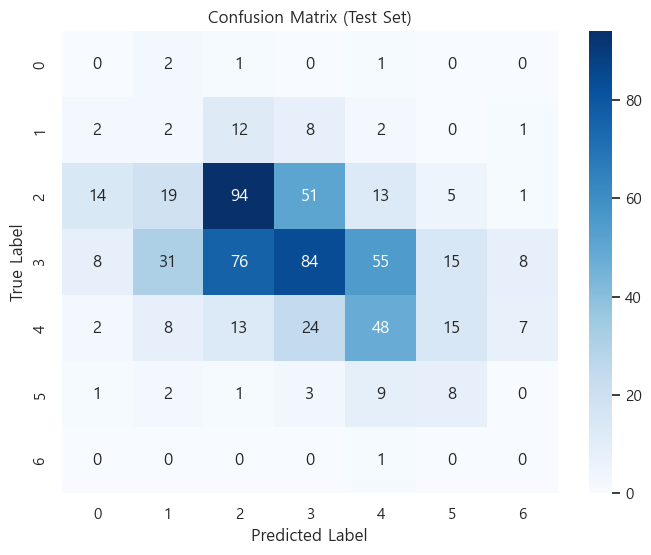

In [47]:
# 방법1: best_model을 직접 사용 (이미 메모리에 있음)
# 테스트 데이터에 파생변수 생성
df_test_processed = create_test_dataset_from_selection(df_test)

# best_model을 직접 사용하여 예측
y_pred = best_model.predict(df_test_processed)

# 동일한 인코더를 사용하여 y_test 변환
y_test_target = le_target.transform(y_test)

# 성능 지표
qwk = cohen_kappa_score(y_test_target, y_pred, weights='quadratic')
print(f"Final Test QWK Score: {qwk:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_target, y_pred))

# 혼동 행렬
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_target, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


### 8.2 회귀모델 - 모델 별 샘플링 정규화 적용


* 결과:
* 분석: 
* 결론:

### 8.3 두 접근 방식의 Accuracy, F1-Score, ROC-AUC를 정량적으로 비교하고 시각화하여 어떤 방식이 더 적합한지 결론을 도출


* 결과:
* 분석: 
* 결론:

### 8.4 모델저장


* 결과:
* 분석: 
* 결론:

### 8.5 모델 선정 분석 보고서


* 결과:
* 분석: 
* 결론:

### 9. 모델 배포


* 결과:
* 분석: 
* 결론:

### 9.1 새로운 데이터 로드 - 4001 번부터 데이터 사용


* 결과:
* 분석: 
* 결론:

### 9.2 모델 사용용

* 결과:
* 분석: 
* 결론: